# Order Income Forecasting: 2025 Retrospective & 2026 Outlook

**Part 0 — Build XGBoost Snapshots**  
For each of 13 point-in-time dates (monthly for 2025 + Jan 2026), identifies open deals, predicts win probability and AFT close date, and saves a parquet file. Run once (or after model/data updates).

**Part 1 — Naive Baseline (CRM Probability + Saledate)**  
Monthly forecasts using only the CRM’s own reported win probability and saledate — no ML model. Includes TP/FP/FN-A/FN-B outcome classification.

**Part 2 — Current Approach (XGBoost + AFT)**  
**2a:** Four quarterly forecasts from dedicated snapshots with a combined Q1–Q4 chart.  
**2b:** Quarterly retrospective — stitched forecast vs actual wins, TP/FP/FN classification.  
**2c:** Monthly forecasts (one snapshot per month) with accuracy evaluation and TP/FP/FN table.

**Part 3 — 2026 Live Forecast**  
Forward-looking Q1 2026 forecast using the January 2026 XGBoost snapshot.

**Part 4 — Probability-Weighted Approach**  
Monthly expected value forecast: `amount × probability` for all deals with probability > 25 %. Includes TP/FP/FN outcome classification.


In [371]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

pd.set_option('display.float_format', '{:,.0f}'.format)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

In [372]:
# ── BUSINESS UNIT LABELS ─────────────────────────────────────────────────────
# Ranked by unique chance IDs active in 2025 (most active = Business Unit 1)
BU_LABELS = {
    '6befd145c261113d': 'Business Unit 1',  # 2,032 deals
    '9387d1da6d5967e1': 'Business Unit 2',  # 1,353 deals
    '1cdd086394501fee': 'Business Unit 3',  # 1,003 deals
    'ac2a5ee6878db2c2': 'Business Unit 4',  #   927 deals
    'a66943a59bca7bfd': 'Business Unit 5',  #   523 deals
    'ef9b14cf5a29c54a': 'Business Unit 6',  #   154 deals
    '4928d3c96935fb3f': 'Business Unit 7',  #   128 deals
}

def apply_bu_labels(df, col='business_unit'):
    """Map raw business_unit hashes to readable labels."""
    df = df.copy()
    df[col] = df[col].map(BU_LABELS).fillna(df[col])
    return df

# ── SHARED COLOUR PALETTE ─────────────────────────────────────────────────────
COLORS = {
    'Optimistic':   '#4C72B0',
    'Base':         '#55A868',
    'Conservative': '#C44E52',
    'Actual':       '#E07B00',  # amber — Part 2 comparison charts only
}

# ── HELPER FUNCTIONS (reused in Parts 1 and 3) ───────────────────────────────
def apply_scenario(df: pd.DataFrame, threshold: float, buffer: float = 0.10) -> pd.DataFrame:
    """Include deal if probability >= threshold; apply flat safety buffer deduction."""
    out = df[df['probability'] >= threshold].copy()
    out['forecasted_amount'] = out['amount'] * (1 - buffer)
    return out


def monthly_revenue(sdf: pd.DataFrame, start_period: str, n_months: int) -> pd.Series:
    """Sum forecasted_amount per calendar month for n_months starting from start_period."""
    months = pd.period_range(start_period, periods=n_months, freq='M')
    sdf = sdf.copy()
    sdf['month'] = sdf['predicted_close_date'].dt.to_period('M')
    return sdf.groupby('month')['forecasted_amount'].sum().reindex(months, fill_value=0)


def segment_summary(sdf: pd.DataFrame, by: str) -> pd.DataFrame:
    """Order Income summary grouped by a CRM dimension (e.g. business_unit)."""
    grp = sdf.groupby(by)['forecasted_amount'].agg(
        total_revenue='sum',
        deal_count='count',
    )
    # Always show all 7 BUs, even those with no deals in the current scenario
    if by == 'business_unit':
        grp = grp.reindex(list(BU_LABELS.keys()), fill_value=0)
    grp = grp.reset_index()
    grp['avg_deal_size']   = grp['total_revenue'] / grp['deal_count'].replace(0, pd.NA)
    grp['revenue_share_%'] = (grp['total_revenue'] / grp['total_revenue'].sum() * 100).round(1)
    return grp.sort_values('total_revenue', ascending=False)


# ── FORECAST THRESHOLDS & RISK FLAGS (shared across all forecast sections) ─────
P1_THRESHOLD_OPT  = 0.55   # min probability — Optimistic scenario
P1_THRESHOLD_BASE = 0.65   # min probability — Base scenario
P1_THRESHOLD_CONS = 0.75   # min probability — Conservative scenario
P1_SAFETY_BUFFER  = 0.0    # revenue safety deduction (0 = none)
P1_MAX_STALE_DAYS = 30     # flag deal if no CRM update for > 30 days
P1_MAX_SHIFTS     = 3      # flag deal if close date moved > 3 times


---

# Part 0 — Build XGBoost Forecast Snapshots

Builds one parquet per snapshot date: monthly for all of 2025 (12 dates) plus January 1, 2026 — 13 total. Each snapshot identifies open CRM chances as of that date, applies the same preprocessing as the training pipeline, predicts win probability and AFT close date, and saves to `data/RQ3 Predictions/`.

**Run once** (or after a model or changelog update). Parts 1–3 load these files directly.


In [373]:
import os
import joblib, json as _json
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# ── CONFIGURATION ────────────────────────────────────────────────────────────
AMOUNT_FLOOR   = 150    # amounts below this → replaced by business_unit median
OUTPUT_DIR     = '../data/RQ3 Predictions'
ARTIFACTS_DIR  = '../data/RQ3 Predictions/model_artifacts'
XGB_MODEL_PATH = '../RQ1/mlruns/0/models/m-8fb20728d8ca4970aaa1b5e89a6be9f5/artifacts/model.ubj'

# Quarterly dates used by Parts 1 & 3
SNAPSHOT_DATES = [
    pd.Timestamp('2025-01-01'),
    pd.Timestamp('2025-04-01'),
    pd.Timestamp('2025-07-01'),
    pd.Timestamp('2025-10-01'),
    pd.Timestamp('2026-01-01'),
]

# Monthly dates for all of 2025 — used by Part 2b
MONTHLY_SNAPSHOT_DATES_2025 = [pd.Timestamp(f'2025-{m:02d}-01') for m in range(1, 13)]

CAT_COLS = ['business_unit', 'responsible', 'registered_by_id', 'updated_by_id',
            'stage_en', 'org_id', 'org_category_en', 'chance_type_en']

AFT_CAT_COLS = ['stage_en_init', 'business_unit', 'org_category_en', 'chance_type_en']

DROP_COLS = [
    'status', 'chance_id', 'registered_dt', 'updated_dt',
    'saledate', 'org_country', 'days_until_saledate', 'target_won',
    'prob_change_last_update', 'prob_volatility', 'amount_pct_change',
    'update_frequency_trend', 'customer_win_ratio', 'is_repeat_customer',
]

os.makedirs(OUTPUT_DIR,    exist_ok=True)
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
print('Configuration ready.')


Configuration ready.


In [374]:
# ── Load model artifacts ─────────────────────────────────────────────────────
# Prerequisite: run the artifact-saving cells in
#   RQ1/RQ1_models_tuning/model_training_evaluation_best_features.ipynb  (imputer, raw/selected features)
#   RQ2/3_Time_to_Event_Prediction.ipynb                                  (AFT model, ordinal encoder)

# XGBoost win-probability classifier
_xgb_booster = xgb.Booster()
_xgb_booster.load_model(XGB_MODEL_PATH)
_imp = joblib.load(f'{ARTIFACTS_DIR}/imputer.joblib')
with open(f'{ARTIFACTS_DIR}/raw_features.json') as _f:
    _raw_features = _json.load(_f)
_selected_features = list(_xgb_booster.feature_names)

# XGBoost AFT close-date predictor
_xgb_aft = xgb.Booster()
_xgb_aft.load_model(f'{ARTIFACTS_DIR}/xgb_aft.json')
_enc_aft = joblib.load(f'{ARTIFACTS_DIR}/ordinal_encoder_aft.joblib')
with open(f'{ARTIFACTS_DIR}/aft_features.json') as _f:
    _aft_features = _json.load(_f)

print(f'Win-probability model: {len(_selected_features)} features (from booster.feature_names)')
print(f'AFT model:             {len(_aft_features)} features')
print(f'Imputer:               {_imp.strategy} strategy, {len(_raw_features)} raw features')

Win-probability model: 15 features (from booster.feature_names)
AFT model:             15 features
Imputer:               median strategy, 35 raw features


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  indent=1,


In [375]:
def _add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add the same 9 interaction / derived features as in the XGBoost training pipeline."""
    df = df.copy()
    df['log_amount']           = np.log1p(df['amount'])
    df['probability_saledate'] = df['probability'] * df['saledate_delta']
    df['amount_deal_share']    = np.log1p(df['amount']) * df['deal_share_rep']
    df['prob_x_closing_rate']  = df['probability'] * df['rep_closing_rate']
    df['age_x_updates']        = df['deal_age'] * df['updates_last_180d']
    df['amount_per_rep']       = df['amount'] / (df['rep_amount'] + 1)
    df['push_ratio']           = df['total_days_pushed'] / (df['saledate_delta'].abs() + 1)
    df['update_intensity']     = df['updates_last_14d'] / (df['deal_age'] + 1)
    df['stage_x_prob']         = df['stage_en'] * df['probability']
    return df

print('Helper function _add_engineered_features defined.')

Helper function _add_engineered_features defined.


In [376]:
def build_forecast_snapshot(snapshot_date: pd.Timestamp,
                             df_cl: pd.DataFrame) -> pd.DataFrame:
    """
    Build a forecast DataFrame of open chances with:
      - XGBoost-predicted win probability (xgb_prob_won)
      - AFT-predicted close date (replaces CRM saledate) → stored as 'closedate'

    Steps
    -----
    1.  Filter changelog ≤ snapshot_date; take latest entry per chance.
    2.  Keep only status = Open; remove stale (not updated in 1 yr).
    3.  Predict close date with XGBoost AFT (init features from first changelog entry).
        Backdate any past predictions to snapshot_date + 7 days.
    4.  Print amount distribution.
    5.  Impute low amounts (< AMOUNT_FLOOR) with business_unit median.
    6.  Save metadata (readable labels, AFT-predicted closedate).
    7.  Label-encode categoricals for XGBoost win model.
    8.  Reindex to raw feature set, apply imputer.
    9.  Add 9 engineered interaction features.
    10. Reindex to selected features, predict win probability.
    11. Assemble and return result.
    """
    lbl = snapshot_date.strftime('%Y-%m-%d')

    # 1. Latest entry per chance as of snapshot_date, keep Open only
    df_snap = df_cl[df_cl['updated_dt'] <= snapshot_date]
    df_open = (
        df_snap
        .sort_values('updated_dt')
        .groupby('chance_id', as_index=False)
        .last()
        .copy()
    )
    df_open = df_open[df_open['status'] == 'Open'].reset_index(drop=True)
    print(f'[{lbl}] Open at last entry:              {len(df_open):,}')

    # 2. Remove stale chances (no update within 1 year)
    stale_mask = df_open['updated_dt'] < (snapshot_date - pd.DateOffset(years=1))
    df_open = df_open[~stale_mask].reset_index(drop=True)
    print(f'[{lbl}] After removing stale (>1 yr):    {len(df_open):,}')

    # 3. Predict close date with XGBoost AFT
    #    Init features = first changelog entry per deal (state at registration)
    first_cols = ['probability', 'amount', 'stage_en', 'days_until_saledate', 'has_products_and_services']
    df_first = (
        df_cl[df_cl['chance_id'].isin(df_open['chance_id'])]
        .sort_values('updated_dt')
        .drop_duplicates('chance_id', keep='first')
        .set_index('chance_id')[first_cols]
        .add_suffix('_init')
    )
    df_open = df_open.join(df_first, on='chance_id', how='left')
    df_open['log_amount_init'] = np.log1p(df_open['amount_init'])

    # Build AFT feature matrix in a copy — do NOT overwrite df_open's categorical columns,
    # as they're still needed as strings for the LabelEncoder step below.
    aft_X = df_open[_aft_features].copy()
    aft_X[AFT_CAT_COLS] = _enc_aft.transform(
        aft_X[AFT_CAT_COLS].fillna('missing').astype(str)
    )

    dm_aft = xgb.DMatrix(
        aft_X.values,
        feature_names=_aft_features,
    )
    pred_days = np.round(_xgb_aft.predict(dm_aft)).astype(int)
    df_open['closedate'] = (
        pd.to_datetime(df_open['registered_dt'])
        + pd.to_timedelta(pred_days, unit='D')
    )
    past_mask = df_open['closedate'] < snapshot_date
    df_open.loc[past_mask, 'closedate'] = snapshot_date + pd.Timedelta(days=7)
    print(f'[{lbl}] AFT close dates predicted — {past_mask.sum():,} backdated to snapshot+7d')

    # 4. Amount distribution (before imputation)
    bins   = [0, 10, 100, 1_000, 10_000, np.inf]
    labels = ['< 10', '10–100', '100–1k', '1k–10k', '≥ 10k']
    dist   = pd.cut(df_open['amount'], bins=bins, labels=labels, right=False).value_counts().reindex(labels)
    print(f'[{lbl}] Amount distribution (n={len(df_open):,}):')
    for lbl_a, cnt in dist.items():
        print(f'    {lbl_a:<10} {cnt:>5,}  ({cnt/len(df_open)*100:.1f}%)')

    # 5. Impute low amounts with business_unit median
    #    (uses the original string business_unit — do this before label-encoding)
    bu_medians = df_open.groupby('business_unit')['amount'].median()
    low_mask   = df_open['amount'] < AMOUNT_FLOOR
    df_open.loc[low_mask, 'amount'] = df_open.loc[low_mask, 'business_unit'].map(bu_medians)
    print(f'[{lbl}] Low amounts imputed:             {low_mask.sum():,}')

    # 6. Save metadata (readable labels + AFT-predicted closedate)
    meta = df_open[[
        'chance_id', 'amount', 'closedate', 'business_unit', 'responsible',
        'close_date_shift', 'updated_dt', 'registered_dt',
    ]].copy()

    # 7. Label-encode categoricals for XGBoost win-probability model
    for col in CAT_COLS:
        if col in df_cl.columns and col in df_open.columns:
            le = LabelEncoder()
            le.fit(df_cl[col].fillna('missing').astype(str))
            df_open[col] = le.transform(df_open[col].fillna('missing').astype(str))

    # 8. Align to raw feature set and apply imputer
    drop_present = [c for c in DROP_COLS if c in df_open.columns]
    X = df_open.drop(columns=drop_present)
    X = X.reindex(columns=_raw_features, fill_value=np.nan)
    X = pd.DataFrame(_imp.transform(X), columns=_raw_features, index=X.index)

    # 9. Add engineered features
    X = _add_engineered_features(X)

    # 10. Reindex to selected features and predict win probability
    X_sel = X.reindex(columns=_selected_features, fill_value=np.nan)
    xgb_prob_won = _xgb_booster.predict(xgb.DMatrix(X_sel))

    # 11. Assemble result
    result = meta.copy()
    result['xgb_prob_won'] = xgb_prob_won
    result = result[[
        'chance_id', 'amount', 'xgb_prob_won', 'closedate',
        'business_unit', 'responsible', 'close_date_shift', 'updated_dt', 'registered_dt',
    ]]

    print(f'[{lbl}] xgb_prob_won range:              '
          f'{result["xgb_prob_won"].min():.3f} – {result["xgb_prob_won"].max():.3f}')
    print()
    return result

print('build_forecast_snapshot defined.')

build_forecast_snapshot defined.


In [377]:
# ── Load changelog and build all snapshots ───────────────────────────────────
df_cl_full = pd.read_parquet('../data/newfeats_repvars_chance_changelog.parquet')
df_cl_full['updated_dt']    = pd.to_datetime(df_cl_full['updated_dt'])
df_cl_full['saledate']      = pd.to_datetime(df_cl_full['saledate'])
df_cl_full['registered_dt'] = pd.to_datetime(df_cl_full['registered_dt'])
print(f'Changelog loaded: {len(df_cl_full):,} rows')
print()

# All dates: quarterly (Parts 1 & 3) + monthly 2025 (Part 2b), deduplicated and sorted
_all_dates = sorted(set(SNAPSHOT_DATES) | set(MONTHLY_SNAPSHOT_DATES_2025))

for snap_date in _all_dates:
    out_path = f'{OUTPUT_DIR}/forecast_{snap_date.strftime("%Y-%m-%d")}.parquet'
    if os.path.exists(out_path):
        print(f'Already exists — skipping {snap_date.strftime("%Y-%m-%d")}')
        continue
    df_snap = build_forecast_snapshot(snap_date, df_cl_full)
    df_snap.to_parquet(out_path, index=False)
    print(f'Saved {len(df_snap):,} rows → {out_path}')
    print()

print('All snapshots ready.')


Changelog loaded: 133,451 rows

Already exists — skipping 2025-01-01
Already exists — skipping 2025-02-01
Already exists — skipping 2025-03-01
Already exists — skipping 2025-04-01
Already exists — skipping 2025-05-01
Already exists — skipping 2025-06-01
Already exists — skipping 2025-07-01
Already exists — skipping 2025-08-01
Already exists — skipping 2025-09-01
Already exists — skipping 2025-10-01
Already exists — skipping 2025-11-01
Already exists — skipping 2025-12-01
Already exists — skipping 2026-01-01
All snapshots ready.


In [378]:
# ── Snapshot preview — structure check after Part 0 ─────────────────────────
# Load the Jan 2025 snapshot as a representative example
_preview = pd.read_parquet(f'{OUTPUT_DIR}/forecast_2025-01-01.parquet')
_preview['closedate'] = pd.to_datetime(_preview['closedate'])

print(f'Shape: {_preview.shape}')
print(f'xgb_prob_won  — min: {_preview["xgb_prob_won"].min():.3f}  '
      f'median: {_preview["xgb_prob_won"].median():.3f}  '
      f'max: {_preview["xgb_prob_won"].max():.3f}')
print(f'closedate (AFT) — min: {_preview["closedate"].min().date()}  '
      f'max: {_preview["closedate"].max().date()}')
_amt_med = _preview['amount'].median() / 1e3
_amt_tot = _preview['amount'].sum() / 1e6
print(f'amount (k)    — median: {_amt_med:.1f}k  total: {_amt_tot:.1f}M')
print()
_preview.head(10)

Shape: (1717, 9)
xgb_prob_won  — min: 0.004  median: 0.293  max: 0.976
closedate (AFT) — min: 2025-01-01  max: 2028-09-25
amount (k)    — median: 37.4k  total: 919.8M



,chance_id,amount,xgb_prob_won,closedate,business_unit,responsible,close_date_shift,updated_dt,registered_dt
0,006eb33286c71362,"89,664",0,2025-01-08 00:00:00,6befd145c261113d,525d39c7687a01be,4,2024-04-24 06:49:20,2023-02-09 13:51:32
1,0070efc1485bb975,"48,556",0,2025-05-21 07:51:49,ac2a5ee6878db2c2,9e271d581fe9a5f9,2,2024-10-29 07:18:37,2024-09-16 07:51:49
2,00a71a2e37b27bfd,"22,962",0,2025-01-08 00:00:00,9387d1da6d5967e1,493efc31b09f958f,1,2024-06-20 12:53:07,2024-04-08 15:28:17
3,00ad5b4a4cd92ca8,"46,341",1,2025-03-07 09:35:24,1cdd086394501fee,1d1184b703d3be2c,0,2024-10-24 12:08:52,2024-10-11 09:35:24
4,00ca16999e29b1c2,"63,257",0,2025-01-08 00:00:00,1cdd086394501fee,8a4c2f62f9eb097e,2,2024-12-02 12:03:24,2024-07-11 07:37:41
5,00f99c4ebebe8a15,"9,649",0,2025-01-08 00:00:00,9387d1da6d5967e1,332ac2afa3a8ddec,2,2024-08-23 12:09:15,2023-11-15 15:51:25
6,0112e9a478a18ece,"9,649",0,2025-03-02 08:48:20,9387d1da6d5967e1,1c6e91fb92ea3dad,0,2024-10-30 08:48:21,2024-10-30 08:48:20
7,0148e465addc6420,"4,143",0,2025-01-08 00:00:00,9387d1da6d5967e1,332ac2afa3a8ddec,5,2024-11-21 13:45:15,2023-12-21 10:13:34
8,017062c1d7d96fef,"211,887",0,2025-04-11 14:17:49,1cdd086394501fee,1473b4c4163229d8,1,2024-12-16 11:55:53,2024-08-23 14:17:49
9,018c7eea8a1f3f67,"46,341",0,2026-01-07 14:48:33,1cdd086394501fee,1482b05113ad67cf,0,2024-02-12 12:36:58,2023-08-30 14:48:33


---

# Part 1 — Naive Baseline (CRM Probability + Saledate)

Uses the CRM's own reported win probability and predicted close date (`saledate`) directly —
no machine learning. For each monthly snapshot, the latest state of every open deal is read
from the changelog. If a deal's `saledate` lies in the past relative to the snapshot date,
it is capped to the snapshot date (mimicking how a rep would report it as still live).

The same three probability scenarios are applied (Optimistic ≥ 55 %, Base ≥ 65 %,
Conservative ≥ 75 %). Results are compared against actual 2025 won deals.


In [379]:
# ── Naive Baseline: data setup ───────────────────────────────────────────────
# df_cl_full already loaded in Part 0. cl (clean changelog) is loaded here for actuals.

cl = pd.read_parquet('../data/clean_chance_changelog.parquet')
cl['updated_dt'] = pd.to_datetime(cl['updated_dt'])
cl['saledate']   = pd.to_datetime(cl['saledate'])

# Actual 2025 won deals — also used by Parts 2 and 4
df_actual = (
    cl[cl['target_won'] == 1]
    .sort_values('updated_dt')
    .groupby('chance_id', as_index=False)
    .last()
)
df_actual = df_actual[
    (df_actual['saledate'] >= '2025-01-01') &
    (df_actual['saledate'] <  '2026-01-01')
].copy()
df_actual = apply_bu_labels(df_actual)
df_actual['month']   = pd.to_datetime(df_actual['saledate']).dt.to_period('M')
df_actual['quarter'] = pd.to_datetime(df_actual['saledate']).dt.to_period('Q').astype(str).map(
    {'2025Q1': 'Q1 2025', '2025Q2': 'Q2 2025', '2025Q3': 'Q3 2025', '2025Q4': 'Q4 2025'}
)
_all_months_2025 = pd.period_range('2025-01', periods=12, freq='M')
actual_monthly = df_actual.groupby('month')['amount'].sum().reindex(_all_months_2025, fill_value=0)

# Month config (same structure as Part 2c; defined here so Naive Baseline is self-contained)
MONTHS_2025 = [
    {'label': f'2025-{m:02d}', 'snapshot': f'2025-{m:02d}-01',
     'start': f'2025-{m:02d}',  'end': f'2025-{m:02d}'}
    for m in range(1, 13)
]

print(f'Actual 2025 won deals: {len(df_actual):,}  |  '
      f'total order income: \u20ac{df_actual["amount"].sum():,.0f}')


Actual 2025 won deals: 2,503  |  total order income: €389,909,427


In [380]:
# ── build_naive_snapshot: CRM probability + saledate, no model ───────────────
def build_naive_snapshot(snapshot_date: pd.Timestamp,
                          df_cl: pd.DataFrame) -> pd.DataFrame:
    """
    Return the latest known state of every open deal as of `snapshot_date`,
    using the raw CRM `probability` and `saledate` (no XGBoost / AFT model).

    Rules:
      - Keep only the most-recent changelog entry per deal up to snapshot_date.
      - Filter to status == 'Open'.
      - Remove deals not updated in the past year (stale).
      - If saledate < snapshot_date, cap it to snapshot_date + 7 days
        (consistent with XGBoost/AFT snapshot; prevents placing a deal on the snapshot boundary).
      - Returns a DataFrame with columns: chance_id, amount, probability,
        predicted_close_date (= naive saledate), business_unit, updated_dt.
    """
    lbl = snapshot_date.strftime('%Y-%m-%d')

    df_snap = df_cl[df_cl['updated_dt'] <= snapshot_date].copy()
    df_snap = (
        df_snap.sort_values('updated_dt')
               .groupby('chance_id', as_index=False)
               .last()
    )

    df_open = df_snap[df_snap['status'] == 'Open'].copy()
    stale_mask = df_open['updated_dt'] < (snapshot_date - pd.DateOffset(years=1))
    df_open = df_open[~stale_mask].reset_index(drop=True)

    # Normalise probability to 0-1 if CRM stores it as 0-100
    if df_open['probability'].max() > 1.0:
        df_open['probability'] = df_open['probability'] / 100.0

    df_open['predicted_close_date'] = pd.to_datetime(df_open['saledate'])
    past_mask = df_open['predicted_close_date'] < snapshot_date
    df_open.loc[past_mask, 'predicted_close_date'] = snapshot_date + pd.Timedelta(days=7)

    print(f'[{lbl}] Naive snapshot: {len(df_open):,} open deals, '
          f'CRM prob range {df_open["probability"].min():.2f}\u2013{df_open["probability"].max():.2f}')

    return df_open[['chance_id', 'amount', 'probability',
                     'predicted_close_date', 'business_unit', 'updated_dt']].copy()


[2025-01-01] Naive snapshot: 1,717 open deals, CRM prob range 0.00–1.00
[2025-02-01] Naive snapshot: 1,689 open deals, CRM prob range 0.00–1.00
[2025-03-01] Naive snapshot: 1,752 open deals, CRM prob range 0.00–1.00
[2025-04-01] Naive snapshot: 1,823 open deals, CRM prob range 0.00–1.00
[2025-05-01] Naive snapshot: 1,841 open deals, CRM prob range 0.00–1.00
[2025-06-01] Naive snapshot: 1,868 open deals, CRM prob range 0.00–1.00
[2025-07-01] Naive snapshot: 1,840 open deals, CRM prob range 0.00–1.00
[2025-08-01] Naive snapshot: 1,858 open deals, CRM prob range 0.00–1.00
[2025-09-01] Naive snapshot: 1,905 open deals, CRM prob range 0.00–1.00
[2025-10-01] Naive snapshot: 1,933 open deals, CRM prob range 0.00–1.00
[2025-11-01] Naive snapshot: 1,866 open deals, CRM prob range 0.00–1.00
[2025-12-01] Naive snapshot: 1,826 open deals, CRM prob range 0.00–1.00


,Deals (Base),Optimistic (€),Base (€),Conservative (€)
Month,,,,
2025-01,116,"€33,993,774","€33,993,774","€19,416,494"
2025-02,94,"€16,459,315","€16,451,874","€12,207,813"
2025-03,119,"€32,148,182","€32,148,182","€24,465,632"
2025-04,143,"€43,591,956","€43,591,956","€24,650,794"
2025-05,137,"€48,097,208","€47,567,781","€30,933,396"
2025-06,188,"€53,264,421","€53,264,421","€35,701,236"
2025-07,169,"€73,198,801","€73,188,887","€62,191,286"
2025-08,143,"€64,888,375","€64,880,934","€42,853,828"
2025-09,161,"€89,049,567","€89,032,211","€72,258,141"


── Accuracy Summary — Naive Baseline, Base Scenario ────────
  MAE (monthly avg)  :  €  28,518,396
  MAPE (monthly avg) :       100.7%
  Total Base Forecast:  € 715,514,349
  Total Actual Won   :  € 389,909,427



,Naive Base Forecast (€),Actual Won (€),Error (€),Abs Error (€),MAPE (%)
Month,,,,,
2025-01,"€33,993,774","€15,704,027","€+18,289,748","€18,289,748",116.5%
2025-02,"€16,451,874","€14,557,536","€+1,894,338","€1,894,338",13.0%
2025-03,"€32,148,182","€40,456,095","€-8,307,913","€8,307,913",20.5%
2025-04,"€43,591,956","€13,898,997","€+29,692,959","€29,692,959",213.6%
2025-05,"€47,567,781","€29,779,547","€+17,788,235","€17,788,235",59.7%
2025-06,"€53,264,421","€19,041,787","€+34,222,634","€34,222,634",179.7%
2025-07,"€73,188,887","€40,621,603","€+32,567,284","€32,567,284",80.2%
2025-08,"€64,880,934","€32,301,355","€+32,579,579","€32,579,579",100.9%
2025-09,"€89,032,211","€47,625,354","€+41,406,856","€41,406,856",86.9%


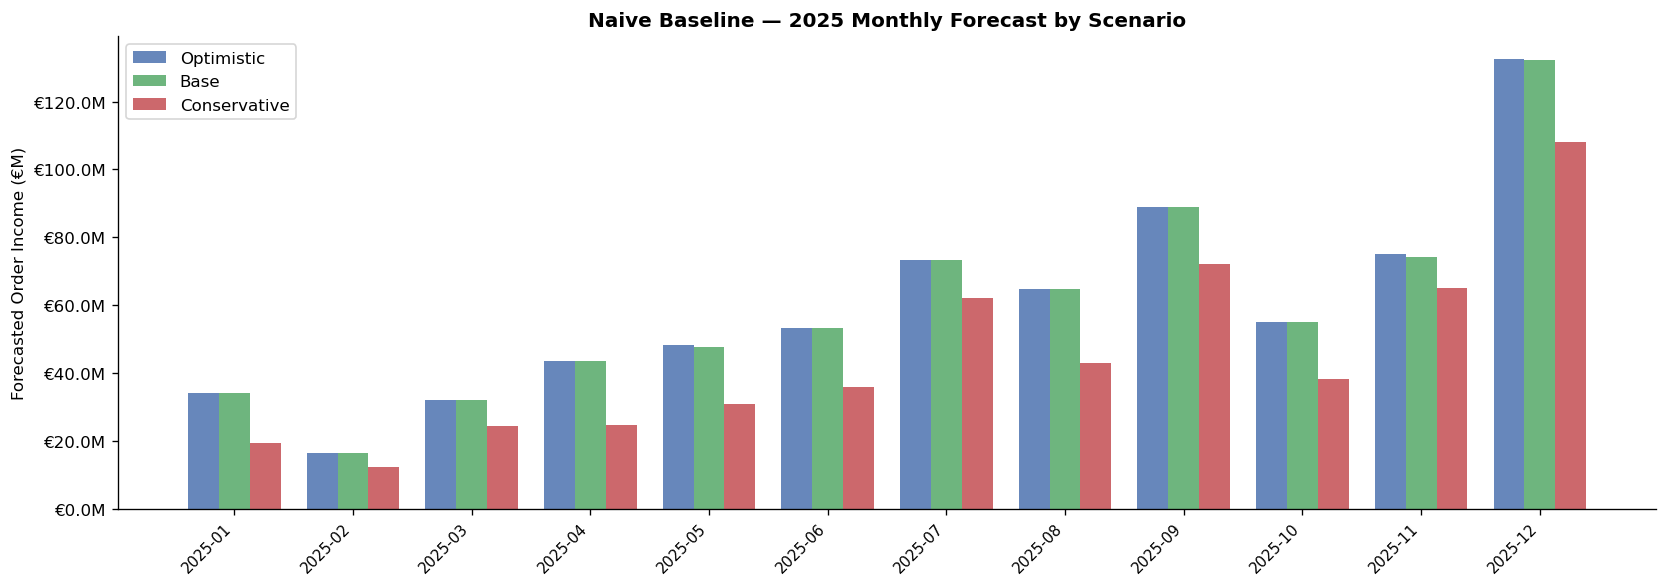

In [381]:
# ── Naive Baseline: monthly forecast loop ────────────────────────────────────
_nb_rows = []
_nb_opt_vals, _nb_base_vals, _nb_cons_vals = [], [], []

# TP/FP tracking
_nb_tp_ids, _nb_fp_ids, _nb_fna_ids = set(), set(), set()
_nb_all_snap_ids   = set()
_nb_all_base_parts = []

for m in MONTHS_2025:
    snap_date = pd.Timestamp(m['snapshot'])
    m_start   = pd.Timestamp(m['start'])
    m_end     = m_start + pd.offsets.MonthEnd(0)

    naive_sdf = build_naive_snapshot(snap_date, df_cl_full)

    # Accumulate all open deals for FN-B
    _nb_all_snap_ids |= set(naive_sdf['chance_id'])

    # Filter to deals whose naive close date falls in this month
    df_nb_m = naive_sdf[
        (naive_sdf['predicted_close_date'] >= m_start) &
        (naive_sdf['predicted_close_date'] <= m_end)
    ].copy()

    df_nb_opt  = apply_scenario(df_nb_m, P1_THRESHOLD_OPT,  P1_SAFETY_BUFFER)
    df_nb_base = apply_scenario(df_nb_m, P1_THRESHOLD_BASE, P1_SAFETY_BUFFER)
    df_nb_cons = apply_scenario(df_nb_m, P1_THRESHOLD_CONS, P1_SAFETY_BUFFER)

    # ── TP/FP accumulation ────────────────────────────────────────────────────
    _act_m     = set(df_actual[df_actual['month'] == pd.Period(m['label'], 'M')]['chance_id'])
    _fcast_nb  = set(df_nb_base['chance_id'])
    _snap_nb   = set(df_nb_m['chance_id'])
    _nb_tp_ids  |= _fcast_nb & _act_m
    _nb_fp_ids  |= _fcast_nb - _act_m
    _nb_fna_ids |= (_snap_nb - _fcast_nb) & _act_m
    if not df_nb_base.empty:
        _nb_all_base_parts.append(df_nb_base)

    rev_nb_opt  = df_nb_opt['forecasted_amount'].sum()
    rev_nb_base = df_nb_base['forecasted_amount'].sum()
    rev_nb_cons = df_nb_cons['forecasted_amount'].sum()

    _nb_opt_vals.append(rev_nb_opt)
    _nb_base_vals.append(rev_nb_base)
    _nb_cons_vals.append(rev_nb_cons)
    _nb_rows.append({
        'Month':            m['label'],
        'Deals (Base)':     len(df_nb_base),
        'Optimistic (\u20ac)': rev_nb_opt,
        'Base (\u20ac)':       rev_nb_base,
        'Conservative (\u20ac)': rev_nb_cons,
    })

# FN-B: won in 2025 but never in any naive snapshot
_nb_fnb_ids = set(df_actual['chance_id']) - _nb_all_snap_ids
_nb_all_base_df = (
    pd.concat(_nb_all_base_parts).drop_duplicates('chance_id')
    if _nb_all_base_parts
    else pd.DataFrame(columns=['chance_id', 'forecasted_amount'])
)

_nb_tbl = pd.DataFrame(_nb_rows).set_index('Month')
display(
    _nb_tbl.style
    .format({
        'Deals (Base)':         '{:,}',
        'Optimistic (\u20ac)':   '\u20ac{:,.0f}',
        'Base (\u20ac)':         '\u20ac{:,.0f}',
        'Conservative (\u20ac)': '\u20ac{:,.0f}',
    })
    .set_caption('Naive Baseline — 2025 Monthly Forecast by Scenario (CRM probability, Base \u2265 65%)')
)

# ── Accuracy summary ──────────────────────────────────────────────────────────
_nb_base_series  = pd.Series(_nb_base_vals, index=_all_months_2025, name='Naive Base Forecast')
_nb_acc          = pd.DataFrame({
    'Month':                   [str(m) for m in _all_months_2025],
    'Naive Base Forecast (\u20ac)': _nb_base_series.values,
    'Actual Won (\u20ac)':         actual_monthly.reindex(_all_months_2025, fill_value=0).values,
}).set_index('Month')
_nb_acc['Error (\u20ac)']     = _nb_acc['Naive Base Forecast (\u20ac)'] - _nb_acc['Actual Won (\u20ac)']
_nb_acc['Abs Error (\u20ac)'] = _nb_acc['Error (\u20ac)'].abs()
_nb_acc['MAPE (%)']           = (
    _nb_acc['Abs Error (\u20ac)'] / _nb_acc['Actual Won (\u20ac)'].replace(0, float('nan')) * 100
).round(1)

_nb_mae  = _nb_acc['Abs Error (\u20ac)'].mean()
_nb_mape = _nb_acc['MAPE (%)'].mean()
print('\u2500\u2500 Accuracy Summary \u2014 Naive Baseline, Base Scenario \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500')
print(f'  MAE (monthly avg)  :  \u20ac{_nb_mae:>12,.0f}')
print(f'  MAPE (monthly avg) :  {_nb_mape:>10.1f}%')
print(f'  Total Base Forecast:  \u20ac{_nb_base_series.sum():>12,.0f}')
print(f'  Total Actual Won   :  \u20ac{actual_monthly.sum():>12,.0f}')
print()

display(
    _nb_acc.style
    .format({
        'Naive Base Forecast (\u20ac)': '\u20ac{:,.0f}',
        'Actual Won (\u20ac)':          '\u20ac{:,.0f}',
        'Error (\u20ac)':               '\u20ac{:+,.0f}',
        'Abs Error (\u20ac)':           '\u20ac{:,.0f}',
        'MAPE (%)':                '  {:.1f}%',
    })
    .set_caption('Naive Baseline \u2014 Monthly Accuracy vs Actual Won')
)

# ── 12-month bar chart ────────────────────────────────────────────────────────
_x_nb = np.arange(12)
_w_nb = 0.26
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(_x_nb - _w_nb, [v / 1e6 for v in _nb_opt_vals],  _w_nb,
       label='Optimistic',   color=COLORS['Optimistic'],   alpha=0.85)
ax.bar(_x_nb,           [v / 1e6 for v in _nb_base_vals], _w_nb,
       label='Base',          color=COLORS['Base'],          alpha=0.85)
ax.bar(_x_nb + _w_nb, [v / 1e6 for v in _nb_cons_vals], _w_nb,
       label='Conservative', color=COLORS['Conservative'], alpha=0.85)
ax.set_xticks(_x_nb)
ax.set_xticklabels([m['label'] for m in MONTHS_2025], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Forecasted Order Income (\u20acM)')
ax.set_title('Naive Baseline \u2014 2025 Monthly Forecast by Scenario', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'\u20ac{v:.1f}M'))
ax.legend()
plt.tight_layout()
plt.show()


In [382]:
# ── Naive Baseline: Outcome Classification ───────────────────────────────────
_nb_tp_rev  = _nb_all_base_df[_nb_all_base_df['chance_id'].isin(_nb_tp_ids)]['forecasted_amount'].sum()
_nb_fp_rev  = _nb_all_base_df[_nb_all_base_df['chance_id'].isin(_nb_fp_ids)]['forecasted_amount'].sum()
_nb_fna_rev = df_actual[df_actual['chance_id'].isin(_nb_fna_ids)]['amount'].sum()
_nb_fnb_rev = df_actual[df_actual['chance_id'].isin(_nb_fnb_ids)]['amount'].sum()

_nb_outcome = pd.DataFrame([
    {'Outcome': 'True Positive  (forecast & won)',         'Deals': len(_nb_tp_ids),  'Order Income (\u20ac)': _nb_tp_rev,  'Note': 'Correctly predicted'},
    {'Outcome': 'False Positive (forecast, not won)',      'Deals': len(_nb_fp_ids),  'Order Income (\u20ac)': _nb_fp_rev,  'Note': 'Over-stated in forecast'},
    {'Outcome': 'False Negative A (in pipeline, missed)',  'Deals': len(_nb_fna_ids), 'Order Income (\u20ac)': _nb_fna_rev, 'Note': 'Below threshold \u2192 won (threshold miss)'},
    {'Outcome': 'False Negative B (structural gap)',       'Deals': len(_nb_fnb_ids), 'Order Income (\u20ac)': _nb_fnb_rev, 'Note': 'Not in pipeline at forecast time'},
]).set_index('Outcome')

print('Deal-Level Outcome Breakdown \u2014 Naive Baseline, Base Scenario (all 12 months)')
display(
    _nb_outcome.style
    .format({'Order Income (\u20ac)': '\u20ac{:,.0f}'})
    .set_caption('Naive Baseline \u2014 Outcome Classification: TP / FP / FN-A / FN-B')
)

# Top 10 False Positives
_nb_fp_table = (
    _nb_all_base_df[_nb_all_base_df['chance_id'].isin(_nb_fp_ids)]
    .nlargest(10, 'forecasted_amount')
    [['chance_id', 'amount', 'probability', 'predicted_close_date', 'forecasted_amount']]
    .reset_index(drop=True)
)
display(
    _nb_fp_table.style
    .format({'amount': '\u20ac{:,.0f}', 'forecasted_amount': '\u20ac{:,.0f}', 'probability': '{:.0%}'})
    .set_caption(f'Naive Baseline \u2014 Top 10 False Positives ({len(_nb_fp_ids)} total)')
    .hide(axis='index')
)


Deal-Level Outcome Breakdown — Naive Baseline, Base Scenario (all 12 months)


,Deals,Order Income (€),Note
Outcome,,,
True Positive (forecast & won),467,"€219,818,013",Correctly predicted
"False Positive (forecast, not won)",632,"€314,989,367",Over-stated in forecast
"False Negative A (in pipeline, missed)",294,"€33,919,184",Below threshold → won (threshold miss)
False Negative B (structural gap),644,"€20,345,407",Not in pipeline at forecast time


chance_id,amount,probability,predicted_close_date,forecasted_amount
97b445a1cf095111,"€59,575,999",100%,2025-12-23 00:00:00,"€59,575,999"
897fee31eed134af,"€16,258,028",77%,2025-07-31 00:00:00,"€16,258,028"
b43f6d4a4e5ebee0,"€15,132,541",77%,2025-11-21 09:19:44,"€15,132,541"
73153abcae95e7df,"€14,830,431",99%,2025-08-31 00:00:00,"€14,830,431"
0d26df31a0969949,"€11,195,772",66%,2025-12-31 00:00:00,"€11,195,772"
9965c3e709531c64,"€10,253,847",77%,2025-05-30 00:00:00,"€10,253,847"
7d6616727a99b64f,"€6,254,155",77%,2025-04-30 00:00:00,"€6,254,155"
aafef84206df1ea5,"€5,891,581",66%,2025-01-08 00:00:00,"€5,891,581"
d53dab1782a7c8ea,"€5,547,541",66%,2025-04-30 00:00:00,"€5,547,541"
9264f15050a133c2,"€5,418,386",77%,2025-08-31 00:00:00,"€5,418,386"


---

# Part 2 — Current Approach (XGBoost + AFT)

## Part 2a — 2025 Quarterly Forecasts

Each quarter uses the pre-built XGBoost snapshot from Part 0. Three probability scenarios
(Optimistic ≥ 55 %, Base ≥ 65 %, Conservative ≥ 75 %) are applied; the Base scenario is used
for all accuracy metrics.


In [383]:
# ── PART 1 CONFIGURATION ─────────────────────────────────────────────────────
QUARTERS_2025 = [
    {'label': 'Q1 2025', 'snapshot': '2025-01-01', 'start': '2025-01', 'end': '2025-03'},
    {'label': 'Q2 2025', 'snapshot': '2025-04-01', 'start': '2025-04', 'end': '2025-06'},
    {'label': 'Q3 2025', 'snapshot': '2025-07-01', 'start': '2025-07', 'end': '2025-09'},
    {'label': 'Q4 2025', 'snapshot': '2025-10-01', 'start': '2025-10', 'end': '2025-12'},
]

# Load pre-built XGBoost snapshot parquets for each quarter
snapshots_2025 = {
    q['snapshot']: pd.read_parquet(f'../data/RQ3 Predictions/forecast_{q["snapshot"]}.parquet')
    for q in QUARTERS_2025
}
print('XGBoost snapshots loaded:')
for snap_lbl, sdf in snapshots_2025.items():
    print(f'  {snap_lbl}: {len(sdf):,} open deals, prob range {sdf["xgb_prob_won"].min():.2f}–{sdf["xgb_prob_won"].max():.2f}')

XGBoost snapshots loaded:
  2025-01-01: 1,717 open deals, prob range 0.00–0.98
  2025-04-01: 1,823 open deals, prob range 0.01–0.95
  2025-07-01: 1,840 open deals, prob range 0.01–0.95
  2025-10-01: 1,933 open deals, prob range 0.01–0.95


In [384]:
def run_quarterly_forecast_2025(q: dict, df_snapshot: pd.DataFrame) -> dict:
    """
    Order Income forecast for one quarter using the pre-built XGBoost snapshot.
    Filters snapshot to deals with closedate in the quarter window, applies
    three probability scenarios, and displays results.
    """
    snap_ts = pd.Timestamp(q['snapshot'])
    q_start = pd.Timestamp(q['start'])
    q_end   = pd.Timestamp(q['end']) + pd.offsets.MonthEnd(0)

    df = df_snapshot[
        (df_snapshot['closedate'] >= q_start) &
        (df_snapshot['closedate'] <= q_end)
    ].copy()
    df = df.rename(columns={
        'xgb_prob_won':  'probability',
        'closedate':     'predicted_close_date',
        'updated_dt':    'last_update_date',
        'registered_dt': 'deal_open_date',
    })
    df['predicted_close_date'] = pd.to_datetime(df['predicted_close_date'])
    df['last_update_date']     = pd.to_datetime(df['last_update_date'])
    df['days_stale']           = (snap_ts - df['last_update_date']).dt.days

    df_opt  = apply_scenario(df, P1_THRESHOLD_OPT,  P1_SAFETY_BUFFER)
    df_base = apply_scenario(df, P1_THRESHOLD_BASE, P1_SAFETY_BUFFER)
    df_cons = apply_scenario(df, P1_THRESHOLD_CONS, P1_SAFETY_BUFFER)

    rev_opt  = monthly_revenue(df_opt,  q['start'], 3)
    rev_base = monthly_revenue(df_base, q['start'], 3)
    rev_cons = monthly_revenue(df_cons, q['start'], 3)
    months   = rev_base.index

    # ── Print summary ────────────────────────────────────────────────────────
    sep = '─' * 60
    print(sep)
    print(f'  {q["label"]}  |  snapshot {q["snapshot"]}')
    print(sep)
    print(f'  Deals in window : {len(df):,}')
    if len(df) > 0:
        print(f'  Prob range      : {df["probability"].min():.2f} – {df["probability"].max():.2f}')
        print(f'  Amount range    : €{df["amount"].min():,.0f} – €{df["amount"].max():,.0f}')
    print()
    for lbl, sdf in [('Optimistic', df_opt), ('Base', df_base), ('Conservative', df_cons)]:
        print(f'  {lbl:14s}: {len(sdf):>3d} deals  |  €{sdf["forecasted_amount"].sum():>12,.0f}')
    print()

    # Monthly forecast table
    tbl = pd.DataFrame({
        'Month':            [str(m) for m in months],
        'Opt Deals':        [(df_opt['predicted_close_date'].dt.to_period('M') == m).sum() for m in months],
        'Base Deals':       [(df_base['predicted_close_date'].dt.to_period('M') == m).sum() for m in months],
        'Cons Deals':       [(df_cons['predicted_close_date'].dt.to_period('M') == m).sum() for m in months],
        'Optimistic (€)':  rev_opt.values,
        'Base (€)':         rev_base.values,
        'Conservative (€)': rev_cons.values,
    }).set_index('Month')
    display(
        tbl.style
        .format({'Optimistic (€)': '€{:,.0f}', 'Base (€)': '€{:,.0f}', 'Conservative (€)': '€{:,.0f}'})
        .set_caption(f'{q["label"]} — Monthly Forecast')
    )

    # Bar chart
    x, width = np.arange(3), 0.26
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(x - width, rev_opt.values  / 1e6, width, label='Optimistic',   color=COLORS['Optimistic'],   alpha=0.85)
    ax.bar(x,         rev_base.values / 1e6, width, label='Base',          color=COLORS['Base'],          alpha=0.85)
    ax.bar(x + width, rev_cons.values / 1e6, width, label='Conservative', color=COLORS['Conservative'], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([str(m) for m in months], fontsize=10)
    ax.set_ylabel('Forecasted Order Income (€M)')
    ax.set_title(f'{q["label"]} — Monthly Order Income by Scenario', fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'€{v:.1f}M'))
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Segment breakdown (Base)
    if len(df_base) > 0:
        seg = apply_bu_labels(segment_summary(df_base, 'business_unit'))
        fig2, ax2 = plt.subplots(figsize=(10, max(3, len(seg) * 0.55)))
        ax2.barh(seg['business_unit'], seg['total_revenue'] / 1e6, color=COLORS['Base'], alpha=0.85)
        ax2.set_xlabel('Forecasted Order Income (€M)')
        ax2.set_title(f'{q["label"]} — Base Order Income by Business Unit', fontweight='bold')
        ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'€{v:.1f}M'))
        ax2.invert_yaxis()
        plt.tight_layout()
        plt.show()
        display(
            seg.style
            .format({'total_revenue': '€{:,.0f}', 'avg_deal_size': '€{:,.0f}', 'revenue_share_%': '{:.1f}%'})
            .hide(axis='index')
            .set_caption(f'{q["label"]} — Base Order Income by Business Unit')
        )

    # Deals at risk (Base) — flag shift > threshold or stale > threshold
    df_risk = df_base[
        (df_base['close_date_shift'] > P1_MAX_SHIFTS) |
        (df_base['days_stale'] > P1_MAX_STALE_DAYS)
    ].copy()

    if len(df_risk) > 0:
        def _reasons(row):
            r = []
            if row['close_date_shift'] > P1_MAX_SHIFTS:
                r.append(f'Date pushed {row["close_date_shift"]}x')
            if row['days_stale'] > P1_MAX_STALE_DAYS:
                r.append(f'No update for {int(row["days_stale"])} days')
            return ' | '.join(r)
        df_risk['risk_reasons'] = df_risk.apply(_reasons, axis=1)

        risk_cols = ['chance_id', 'amount', 'probability', 'predicted_close_date',
                     'close_date_shift', 'last_update_date', 'risk_reasons']
        df_risk_sorted = df_risk[risk_cols].sort_values('amount', ascending=False).reset_index(drop=True)
        n_risk = len(df_risk_sorted)
        print(f'  Deals at risk: {n_risk} of {len(df_base)} Base deals  |  €{df_risk["forecasted_amount"].sum():,.0f}')
        display(
            df_risk_sorted.head(10).style
            .format({'amount': '€{:,.0f}', 'probability': '{:.0%}'})
            .set_caption(f'{q["label"]} — Top 10 of {n_risk} Deals at Risk (Base Scenario)')
            .hide(axis='index')
        )
    else:
        print(f'  No deals at risk for {q["label"]}.')
    print()

    return {
        'label':    q['label'],
        'snap_ts':  snap_ts,
        'rev_opt':  rev_opt,
        'rev_base': rev_base,
        'rev_cons': rev_cons,
        'df_opt':   df_opt,
        'df_base':  df_base,
        'df_cons':  df_cons,
        'df_all':   df,
    }

In [385]:
# ── 2025 Quarterly Actuals Display ───────────────────────────────────────────
# df_actual is defined in Part 1 (Naive Baseline setup); reused here.
_q_actuals = df_actual.groupby('quarter').agg(
    won_deals=('chance_id', 'count'),
    amount=('amount', 'sum'),
).reindex(['Q1 2025', 'Q2 2025', 'Q3 2025', 'Q4 2025'])
_q_actuals.loc['Total'] = _q_actuals.sum()
_q_actuals.index.name = 'Quarter'

print(f'Actual 2025 won deals: {len(df_actual):,}  |  total order income: €{df_actual["amount"].sum():,.0f}')
display(
    _q_actuals.style
    .format({'won_deals': '{:,}', 'amount': '€{:,.0f}'})
    .set_caption('2025 Actual Won Deals by Quarter')
)


Actual 2025 won deals: 2,503  |  total order income: €389,909,427


,won_deals,amount
Quarter,,
Q1 2025,566.0,"€70,717,658"
Q2 2025,562.0,"€62,720,331"
Q3 2025,625.0,"€120,548,312"
Q4 2025,750.0,"€135,923,125"
Total,"2,503.0","€389,909,427"


────────────────────────────────────────────────────────────
  Q1 2025  |  snapshot 2025-01-01
────────────────────────────────────────────────────────────
  Deals in window : 1,346
  Prob range      : 0.00 – 0.98
  Amount range    : €164 – €17,169,141

  Optimistic    : 403 deals  |  €  67,776,421
  Base          : 291 deals  |  €  42,349,196
  Conservative  : 162 deals  |  €  27,307,664



,Opt Deals,Base Deals,Cons Deals,Optimistic (€),Base (€),Conservative (€)
Month,,,,,,
2025-01,304,222,127,"€47,313,249","€24,658,999","€13,572,474"
2025-02,63,44,24,"€14,167,524","€12,504,181","€12,007,613"
2025-03,36,25,11,"€6,295,648","€5,186,015","€1,727,576"


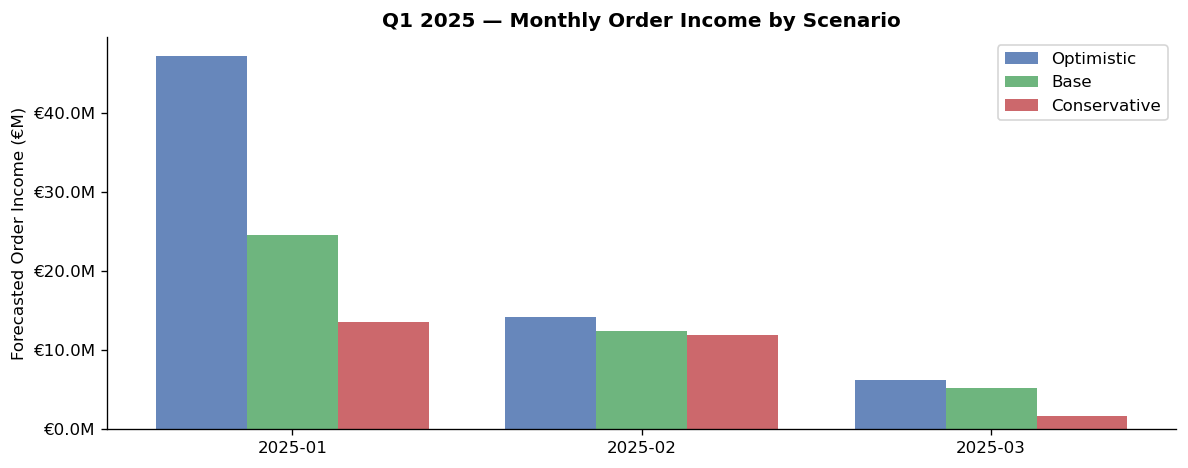

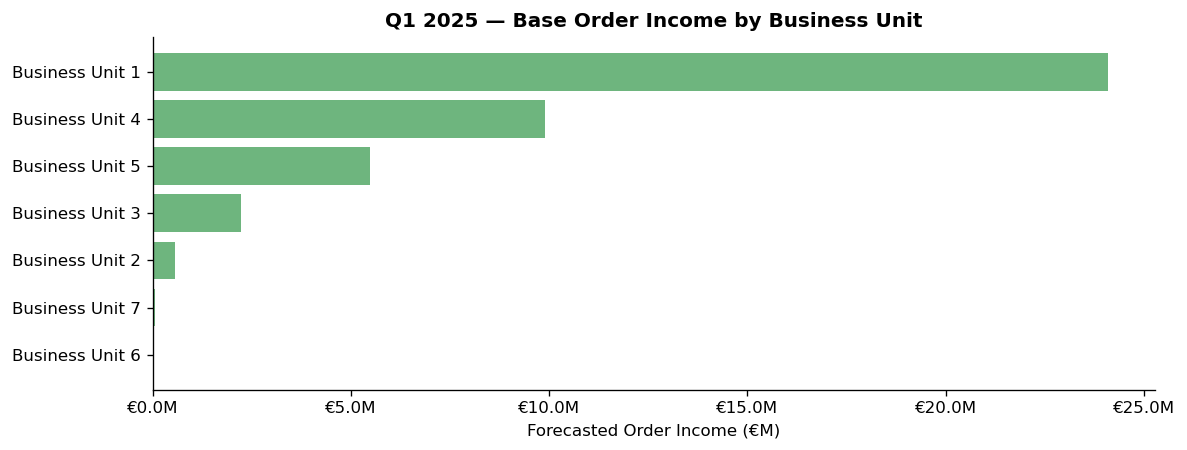

business_unit,total_revenue,deal_count,avg_deal_size,revenue_share_%
Business Unit 1,"€24,077,143",148,"€162,683",56.9%
Business Unit 4,"€9,906,830",57,"€173,804",23.4%
Business Unit 5,"€5,492,096",22,"€249,641",13.0%
Business Unit 3,"€2,233,303",24,"€93,054",5.3%
Business Unit 2,"€563,306",31,"€18,171",1.3%
Business Unit 7,"€55,244",8,"€6,906",0.1%
Business Unit 6,"€21,273",1,"€21,273",0.1%


  Deals at risk: 119 of 291 Base deals  |  €18,225,678


chance_id,amount,probability,predicted_close_date,close_date_shift,last_update_date,risk_reasons
4e5bddbeea7b1996,"€4,967,197",91%,2025-01-08 00:00:00,22,2024-12-20 11:41:08,Date pushed 22x
4cc29d62c95a6317,"€3,684,003",74%,2025-01-08 00:00:00,16,2024-12-16 13:38:28,Date pushed 16x
f9212a7c2adb793d,"€2,784,775",74%,2025-03-27 17:59:39,0,2024-11-07 18:37:43,No update for 54 days
7b764f50165d3f19,"€1,338,120",72%,2025-01-08 00:00:00,22,2024-12-05 11:19:57,Date pushed 22x
05cedfc3d26593a9,"€937,887",79%,2025-02-26 09:59:23,0,2024-11-26 13:12:15,No update for 35 days
2d93dcd959f7632d,"€881,349",86%,2025-01-08 00:00:00,0,2024-11-18 13:09:57,No update for 43 days
0c6f798c8fc875ee,"€510,169",65%,2025-01-08 00:00:00,5,2024-11-29 10:56:46,Date pushed 5x | No update for 32 days
15f66e6cb3621b1f,"€443,371",76%,2025-01-08 00:00:00,0,2024-01-03 11:44:29,No update for 363 days
a19ea97ae50e9c74,"€143,524",78%,2025-01-08 00:00:00,0,2024-10-02 12:30:36,No update for 90 days
12d6bd42a44f74ef,"€142,232",71%,2025-01-19 17:50:32,0,2024-11-07 18:36:44,No update for 54 days



────────────────────────────────────────────────────────────
  Q2 2025  |  snapshot 2025-04-01
────────────────────────────────────────────────────────────
  Deals in window : 1,351
  Prob range      : 0.01 – 0.95
  Amount range    : €182 – €14,621,079

  Optimistic    : 432 deals  |  €  58,774,167
  Base          : 294 deals  |  €  39,642,772
  Conservative  : 136 deals  |  €  11,867,568



,Opt Deals,Base Deals,Cons Deals,Optimistic (€),Base (€),Conservative (€)
Month,,,,,,
2025-04,288,198,92,"€44,920,376","€30,196,956","€7,250,608"
2025-05,98,65,30,"€6,581,164","€5,242,232","€2,208,758"
2025-06,46,31,14,"€7,272,627","€4,203,584","€2,408,202"


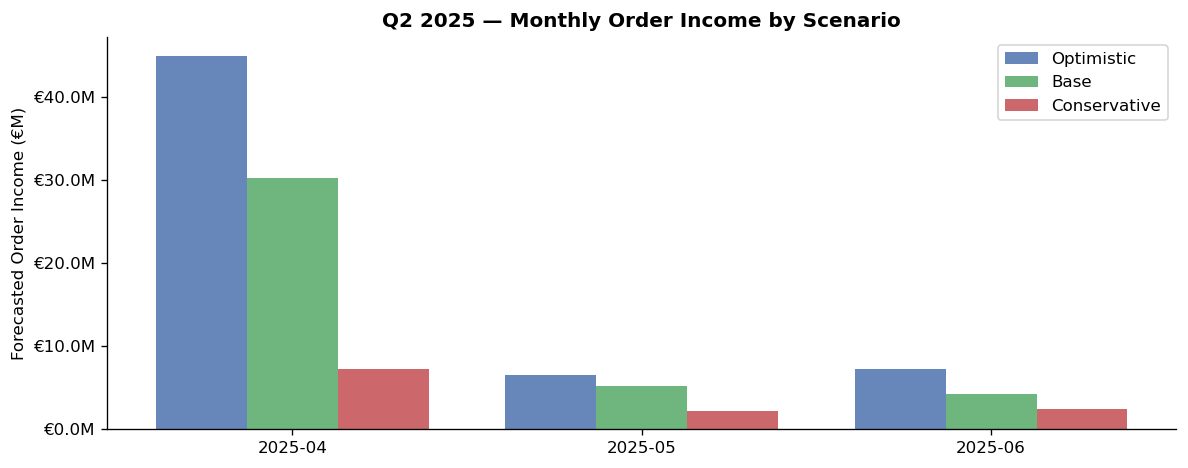

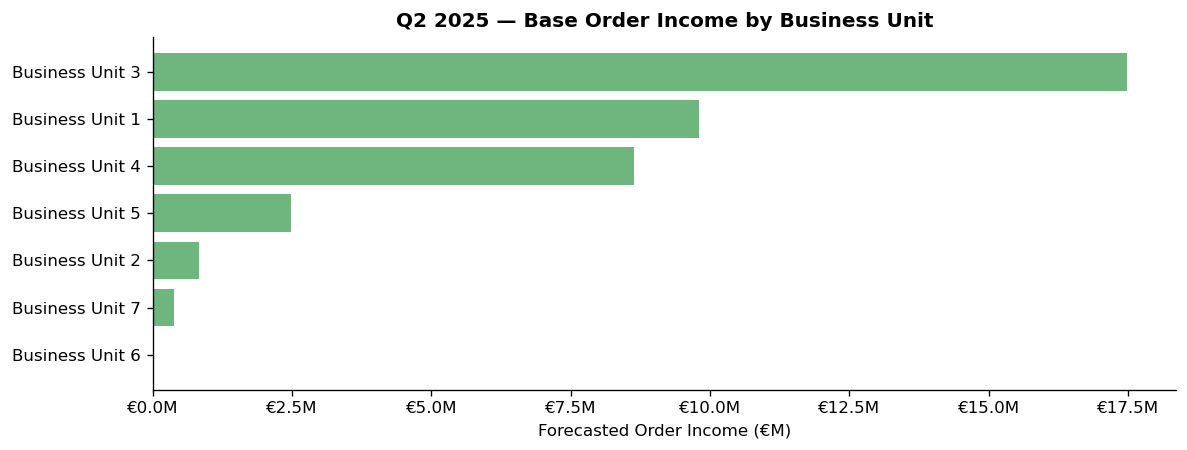

business_unit,total_revenue,deal_count,avg_deal_size,revenue_share_%
Business Unit 3,"€17,488,685",32,"€546,521",44.1%
Business Unit 1,"€9,803,633",152,"€64,498",24.7%
Business Unit 4,"€8,636,311",49,"€176,251",21.8%
Business Unit 5,"€2,490,147",23,"€108,267",6.3%
Business Unit 2,"€835,063",27,"€30,928",2.1%
Business Unit 7,"€383,538",10,"€38,354",1.0%
Business Unit 6,"€5,394",1,"€5,394",0.0%


  Deals at risk: 132 of 294 Base deals  |  €24,810,131


chance_id,amount,probability,predicted_close_date,close_date_shift,last_update_date,risk_reasons
73153abcae95e7df,"€13,788,384",67%,2025-04-08 00:00:00,11,2025-03-18 16:50:50,Date pushed 11x
4cc29d62c95a6317,"€1,078,313",87%,2025-04-08 00:00:00,16,2025-03-31 13:38:33,Date pushed 16x
93c781fa04289de9,"€1,063,051",67%,2025-04-08 00:00:00,5,2025-03-31 08:36:35,Date pushed 5x
ecbc6334ff0603a1,"€933,060",71%,2025-04-08 00:00:00,2,2025-02-07 09:44:24,No update for 52 days
2ca06b546b1c79c7,"€854,463",80%,2025-04-08 00:00:00,5,2025-03-24 14:23:22,Date pushed 5x
cb281d039e6864f0,"€817,503",66%,2025-04-08 00:00:00,4,2025-03-18 15:42:54,Date pushed 4x
06951ec683e300a3,"€692,486",73%,2025-04-08 00:00:00,8,2025-03-31 06:54:10,Date pushed 8x
ad220c1149a7e301,"€362,739",78%,2025-04-08 00:00:00,0,2025-02-28 07:39:28,No update for 31 days
3e8bcc0937383c07,"€309,521",67%,2025-04-08 00:00:00,8,2025-03-28 10:14:25,Date pushed 8x
68495bee29a23167,"€262,741",75%,2025-05-31 15:20:41,0,2025-02-13 17:32:32,No update for 46 days



────────────────────────────────────────────────────────────
  Q3 2025  |  snapshot 2025-07-01
────────────────────────────────────────────────────────────
  Deals in window : 1,358
  Prob range      : 0.01 – 0.95
  Amount range    : €164 – €58,100,920

  Optimistic    : 383 deals  |  €  70,578,345
  Base          : 261 deals  |  €  46,412,897
  Conservative  : 121 deals  |  €  21,427,066



,Opt Deals,Base Deals,Cons Deals,Optimistic (€),Base (€),Conservative (€)
Month,,,,,,
2025-07,277,196,91,"€54,105,821","€37,609,907","€17,250,807"
2025-08,61,36,19,"€10,507,835","€4,092,092","€3,601,320"
2025-09,45,29,11,"€5,964,689","€4,710,898","€574,939"


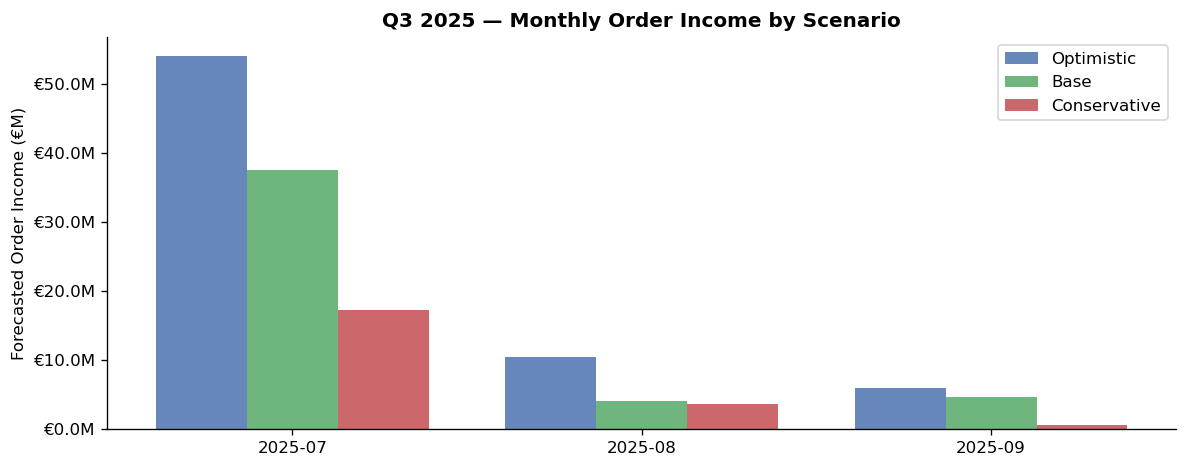

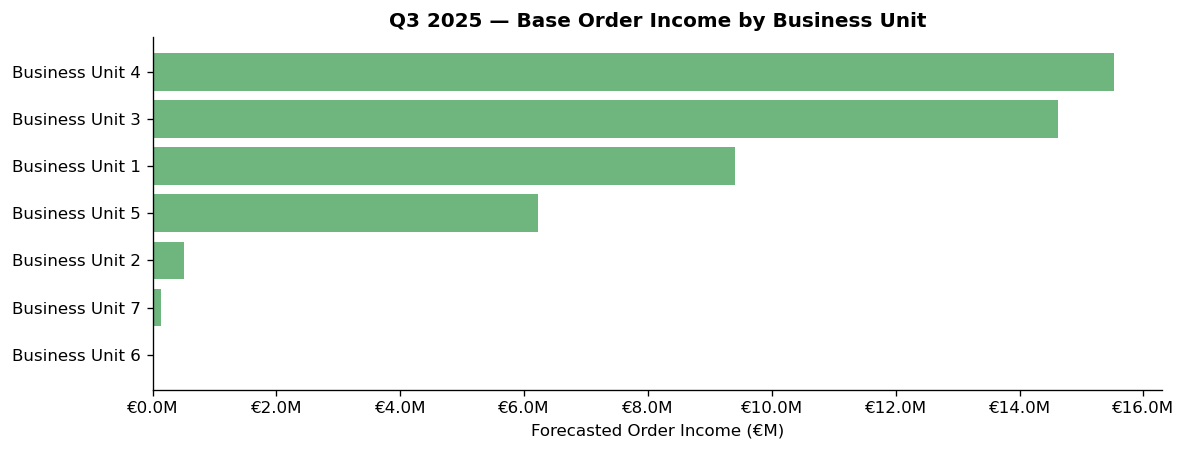

business_unit,total_revenue,deal_count,avg_deal_size,revenue_share_%
Business Unit 4,"€15,524,679",51,"€304,405",33.4%
Business Unit 3,"€14,627,340",24,"€609,472",31.5%
Business Unit 1,"€9,398,081",148,"€63,501",20.2%
Business Unit 5,"€6,230,711",17,"€366,512",13.4%
Business Unit 2,"€500,976",18,"€27,832",1.1%
Business Unit 7,"€131,109",3,"€43,703",0.3%
Business Unit 6,€0,0,€,0.0%


  Deals at risk: 145 of 261 Base deals  |  €23,298,989


chance_id,amount,probability,predicted_close_date,close_date_shift,last_update_date,risk_reasons
73153abcae95e7df,"€10,182,613",74%,2025-07-08 00:00:00,12,2025-04-29 13:01:13,Date pushed 12x | No update for 62 days
3ccf651d218e9851,"€2,048,531",71%,2025-07-08 00:00:00,11,2025-06-19 20:04:14,Date pushed 11x
6f1df902e211b394,"€1,753,502",72%,2025-09-06 13:54:48,0,2025-05-19 08:45:44,No update for 42 days
e02ea23199c9a628,"€1,246,249",69%,2025-07-08 00:00:00,2,2025-05-16 08:58:58,No update for 45 days
3d4dd222a43fd774,"€847,123",68%,2025-07-08 00:00:00,5,2025-06-26 09:24:38,Date pushed 5x
d41928e13964f231,"€760,754",71%,2025-07-08 00:00:00,5,2025-06-26 09:31:40,Date pushed 5x
2ca06b546b1c79c7,"€702,468",86%,2025-07-08 00:00:00,5,2025-06-24 13:18:19,Date pushed 5x
06951ec683e300a3,"€692,486",83%,2025-07-08 00:00:00,9,2025-06-02 06:54:20,Date pushed 9x
2d803d2b58f08a19,"€647,066",84%,2025-07-04 07:08:57,0,2025-05-27 13:33:19,No update for 34 days
778cb39c1c3eec05,"€350,354",77%,2025-08-22 07:49:34,2,2025-04-29 12:13:39,No update for 62 days



────────────────────────────────────────────────────────────
  Q4 2025  |  snapshot 2025-10-01
────────────────────────────────────────────────────────────
  Deals in window : 1,436
  Prob range      : 0.01 – 0.95
  Amount range    : €163 – €58,100,920

  Optimistic    : 451 deals  |  €  71,913,036
  Base          : 312 deals  |  €  49,304,178
  Conservative  : 140 deals  |  €  26,869,624



,Opt Deals,Base Deals,Cons Deals,Optimistic (€),Base (€),Conservative (€)
Month,,,,,,
2025-10,289,206,95,"€49,354,379","€29,854,444","€16,277,479"
2025-11,92,59,28,"€5,307,061","€4,117,184","€982,092"
2025-12,70,47,17,"€17,251,596","€15,332,550","€9,610,053"


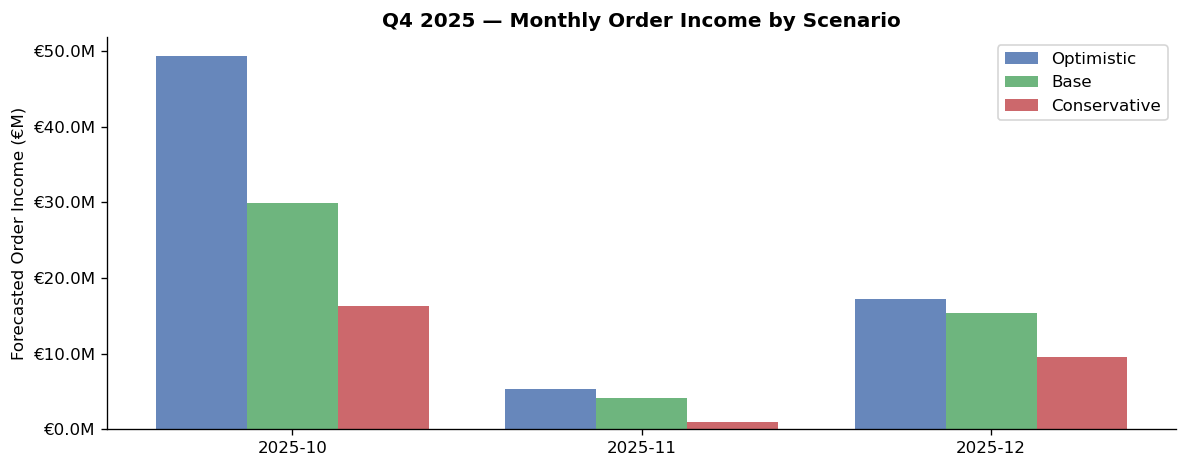

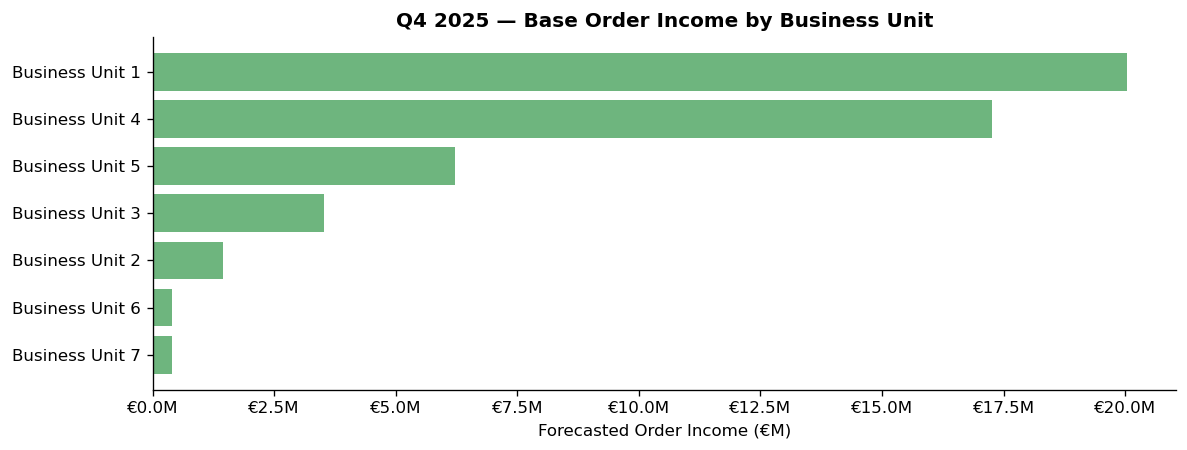

business_unit,total_revenue,deal_count,avg_deal_size,revenue_share_%
Business Unit 1,"€20,042,480",171,"€117,207",40.7%
Business Unit 4,"€17,267,749",56,"€308,353",35.0%
Business Unit 5,"€6,217,525",18,"€345,418",12.6%
Business Unit 3,"€3,525,435",33,"€106,831",7.2%
Business Unit 2,"€1,453,454",27,"€53,832",2.9%
Business Unit 6,"€407,573",1,"€407,573",0.8%
Business Unit 7,"€389,962",6,"€64,994",0.8%


  Deals at risk: 139 of 312 Base deals  |  €23,048,195


chance_id,amount,probability,predicted_close_date,close_date_shift,last_update_date,risk_reasons
9bcd13f0e24175cc,"€6,444,061",69%,2025-10-08 00:00:00,7,2025-09-17 06:23:05,Date pushed 7x
83ed789e45032c29,"€3,593,520",82%,2025-10-08 00:00:00,4,2025-09-30 08:52:05,Date pushed 4x
3ccf651d218e9851,"€2,048,531",81%,2025-10-08 00:00:00,13,2025-09-24 09:33:26,Date pushed 13x
26b19aa0a21e785c,"€1,908,415",81%,2025-10-08 00:00:00,11,2025-09-17 14:00:34,Date pushed 11x
ec7f17fc83765066,"€1,747,633",83%,2025-10-08 00:00:00,5,2025-08-29 09:11:10,Date pushed 5x | No update for 32 days
255d3af624e2d889,"€993,734",77%,2025-10-08 00:00:00,7,2025-08-26 08:06:34,Date pushed 7x | No update for 35 days
ebea6b59d1ff695b,"€538,157",69%,2025-12-25 14:02:53,2,2025-07-04 10:51:09,No update for 88 days
61e99c450c280dd9,"€475,792",73%,2025-10-17 07:30:15,0,2025-08-18 08:57:54,No update for 43 days
55a46035d8950b6e,"€427,983",69%,2025-10-08 00:00:00,7,2025-09-29 13:22:17,Date pushed 7x
70991553e9328c7a,"€397,122",76%,2025-10-08 00:00:00,2,2025-08-11 07:06:02,No update for 50 days


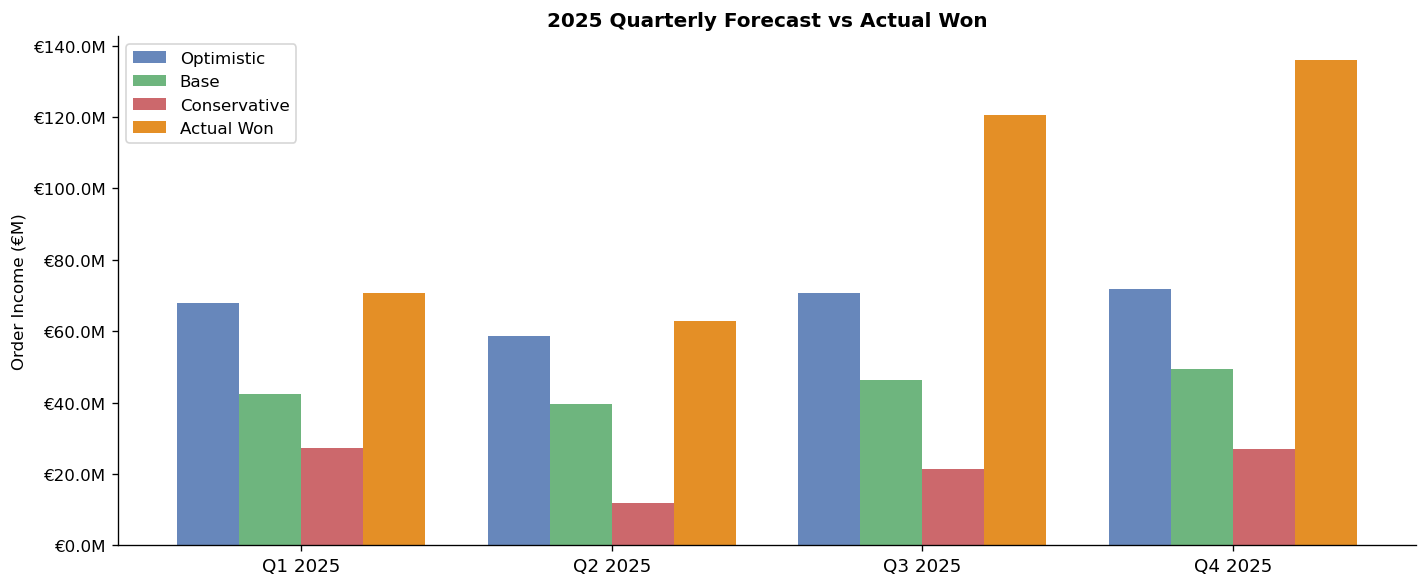

,Base Forecast (€),Actual Won (€),Error (€),Error (%)
Quarter,,,,
Q1 2025,"€42,349,196","€70,717,658","€-28,368,463",-40.1%
Q2 2025,"€39,642,772","€62,720,331","€-23,077,559",-36.8%
Q3 2025,"€46,412,897","€120,548,312","€-74,135,415",-61.5%
Q4 2025,"€49,304,178","€135,923,125","€-86,618,947",-63.7%
Total,"€177,709,042","€389,909,427","€-212,200,384",-54.4%


In [386]:
# ── Run all 4 quarterly forecasts ────────────────────────────────────────────
all_results_2025 = []
for q in QUARTERS_2025:
    res = run_quarterly_forecast_2025(q, snapshots_2025[q['snapshot']])
    all_results_2025.append(res)

q1, q2, q3, q4 = all_results_2025

# ── Combined Q1–Q4 bar chart + accuracy table ────────────────────────────────
_q_ranges = {
    'Q1 2025': ('2025-01-01', '2025-03-31'), 'Q2 2025': ('2025-04-01', '2025-06-30'),
    'Q3 2025': ('2025-07-01', '2025-09-30'), 'Q4 2025': ('2025-10-01', '2025-12-31'),
}
_actual_q = {
    lbl: df_actual[(df_actual['saledate'] >= s) & (df_actual['saledate'] <= e)]['amount'].sum()
    for lbl, (s, e) in _q_ranges.items()
}

q_labels  = [r['label'] for r in all_results_2025]
opt_vals  = [r['rev_opt'].sum()  / 1e6 for r in all_results_2025]
base_vals = [r['rev_base'].sum() / 1e6 for r in all_results_2025]
cons_vals = [r['rev_cons'].sum() / 1e6 for r in all_results_2025]
act_vals  = [_actual_q[lbl]      / 1e6 for lbl in q_labels]

x, width = np.arange(4), 0.20
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 1.5*width, opt_vals,  width, label='Optimistic',   color=COLORS['Optimistic'],   alpha=0.85)
ax.bar(x - 0.5*width, base_vals, width, label='Base',          color=COLORS['Base'],          alpha=0.85)
ax.bar(x + 0.5*width, cons_vals, width, label='Conservative', color=COLORS['Conservative'], alpha=0.85)
ax.bar(x + 1.5*width, act_vals,  width, label='Actual Won',   color=COLORS['Actual'],        alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(q_labels, fontsize=11)
ax.set_ylabel('Order Income (€M)')
ax.set_title('2025 Quarterly Forecast vs Actual Won', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'€{v:.1f}M'))
ax.legend()
plt.tight_layout()
plt.show()

_rows = []
for res in all_results_2025:
    fc, act = res['rev_base'].sum(), _actual_q[res['label']]
    err = fc - act
    _rows.append({'Quarter': res['label'], 'Base Forecast (€)': fc,
                  'Actual Won (€)': act, 'Error (€)': err,
                  'Error (%)': err / act * 100 if act > 0 else float('nan')})
_fc_tot  = sum(r['Base Forecast (€)'] for r in _rows)
_act_tot = sum(r['Actual Won (€)'] for r in _rows)
_err_tot = _fc_tot - _act_tot
_rows.append({'Quarter': 'Total', 'Base Forecast (€)': _fc_tot, 'Actual Won (€)': _act_tot,
              'Error (€)': _err_tot, 'Error (%)': _err_tot / _act_tot * 100 if _act_tot > 0 else float('nan')})
display(
    pd.DataFrame(_rows).set_index('Quarter').style
    .format({'Base Forecast (€)': '€{:,.0f}', 'Actual Won (€)': '€{:,.0f}',
             'Error (€)': '€{:+,.0f}', 'Error (%)': '{:+.1f}%'})
    .set_caption('2025 Quarterly Forecast vs Actual — Base Scenario')
)


---

## Part 2b — 2025 Retrospective: Forecast vs. Actual

The quarterly forecasts are stitched into a 12-month view and compared against the actual
2025 won deals. Each deal is classified as TP / FP / FN-A / FN-B based on the Base scenario.


In [387]:
# ── Stitch quarterly forecasts into 12-month series ──────────────────────────
# df_actual was computed in Part 1 (actuals overview cell)
all_months     = pd.period_range('2025-01', periods=12, freq='M')
stitched_opt   = pd.concat([r['rev_opt']  for r in all_results_2025]).reindex(all_months, fill_value=0)
stitched_base  = pd.concat([r['rev_base'] for r in all_results_2025]).reindex(all_months, fill_value=0)
stitched_cons  = pd.concat([r['rev_cons'] for r in all_results_2025]).reindex(all_months, fill_value=0)
actual_monthly = df_actual.groupby('month')['amount'].sum().reindex(all_months, fill_value=0)

print('Stitched forecast totals vs actual won:')
print('─' * 50)
for label, series in [('Optimistic', stitched_opt), ('Base', stitched_base), ('Conservative', stitched_cons)]:
    print(f'  {label:14s}: €{series.sum():>14,.0f}')
print(f'  {"Actual Won":14s}: €{actual_monthly.sum():>14,.0f}')


Stitched forecast totals vs actual won:
──────────────────────────────────────────────────
  Optimistic    : €   269,041,969
  Base          : €   177,709,042
  Conservative  : €    87,471,922
  Actual Won    : €   389,909,427


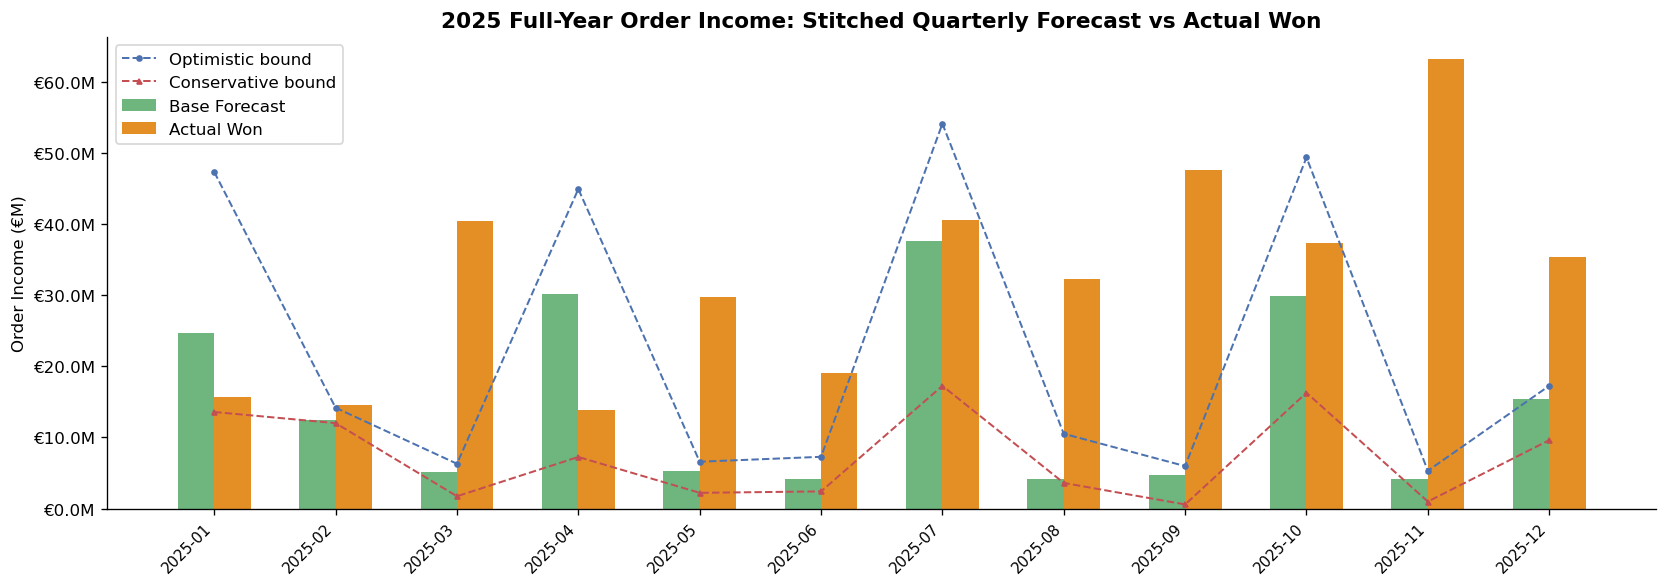

In [388]:
# ── FULL-YEAR MONTHLY COMPARISON BAR CHART ────────────────────────────────────
x           = np.arange(12)
width       = 0.30
month_labels = [str(m) for m in all_months]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width / 2, stitched_base.values  / 1e6, width,
       label='Base Forecast', color=COLORS['Base'],   alpha=0.85)
ax.bar(x + width / 2, actual_monthly.values / 1e6, width,
       label='Actual Won',    color=COLORS['Actual'],  alpha=0.85)
ax.plot(x, stitched_opt.values  / 1e6, color=COLORS['Optimistic'],   lw=1.2, ls='--',
        marker='o', ms=3, label='Optimistic bound')
ax.plot(x, stitched_cons.values / 1e6, color=COLORS['Conservative'], lw=1.2, ls='--',
        marker='^', ms=3, label='Conservative bound')

ax.set_xticks(x)
ax.set_xticklabels(month_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Order Income (\u20acM)')
ax.set_title('2025 Full-Year Order Income: Stitched Quarterly Forecast vs Actual Won',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'\u20ac{v:.1f}M'))
ax.legend()
plt.tight_layout()
plt.show()

In [389]:
# ── MONTHLY ACCURACY METRICS TABLE ────────────────────────────────────────────
acc = pd.DataFrame({
    'Month':             month_labels,
    'Base Forecast (\u20ac)': stitched_base.values,
    'Actual Won (\u20ac)':    actual_monthly.values,
}).set_index('Month')

acc['Error (\u20ac)']     = acc['Base Forecast (\u20ac)'] - acc['Actual Won (\u20ac)']
acc['Abs Error (\u20ac)'] = acc['Error (\u20ac)'].abs()
acc['MAPE (%)']      = (
    acc['Abs Error (\u20ac)'] / acc['Actual Won (\u20ac)'].replace(0, np.nan) * 100
).round(1)

mae      = acc['Abs Error (\u20ac)'].mean()
mape_avg = acc['MAPE (%)'].mean()
total_fc  = acc['Base Forecast (\u20ac)'].sum()
total_act = acc['Actual Won (\u20ac)'].sum()
total_err = total_fc - total_act

print('\u2500\u2500 Accuracy Summary (Base Scenario vs Actual Won) \u2500\u2500\u2500\u2500\u2500\u2500\u2500')
print(f'  MAE (monthly avg)  :  \u20ac{mae:>12,.0f}')
print(f'  MAPE (monthly avg) :  {mape_avg:>10.1f}%')
print(f'  Total Base Forecast:  \u20ac{total_fc:>12,.0f}')
print(f'  Total Actual Won   :  \u20ac{total_act:>12,.0f}')
print(f'  Total Error        :  \u20ac{total_err:>+12,.0f}')
print()

display(
    acc.style
    .format({
        'Base Forecast (\u20ac)': '\u20ac{:,.0f}',
        'Actual Won (\u20ac)':    '\u20ac{:,.0f}',
        'Error (\u20ac)':         '\u20ac{:+,.0f}',
        'Abs Error (\u20ac)':     '\u20ac{:,.0f}',
        'MAPE (%)':          '{:.1f}%',
    })
    .set_caption('Monthly Accuracy Metrics \u2014 Base Scenario vs Actual Won')
)

── Accuracy Summary (Base Scenario vs Actual Won) ───────
  MAE (monthly avg)  :  €  21,892,187
  MAPE (monthly avg) :        65.9%
  Total Base Forecast:  € 177,709,042
  Total Actual Won   :  € 389,909,427
  Total Error        :  €-212,200,384



,Base Forecast (€),Actual Won (€),Error (€),Abs Error (€),MAPE (%)
Month,,,,,
2025-01,"€24,658,999","€15,704,027","€+8,954,972","€8,954,972",57.0%
2025-02,"€12,504,181","€14,557,536","€-2,053,355","€2,053,355",14.1%
2025-03,"€5,186,015","€40,456,095","€-35,270,080","€35,270,080",87.2%
2025-04,"€30,196,956","€13,898,997","€+16,297,958","€16,297,958",117.3%
2025-05,"€5,242,232","€29,779,547","€-24,537,315","€24,537,315",82.4%
2025-06,"€4,203,584","€19,041,787","€-14,838,203","€14,838,203",77.9%
2025-07,"€37,609,907","€40,621,603","€-3,011,696","€3,011,696",7.4%
2025-08,"€4,092,092","€32,301,355","€-28,209,263","€28,209,263",87.3%
2025-09,"€4,710,898","€47,625,354","€-42,914,456","€42,914,456",90.1%


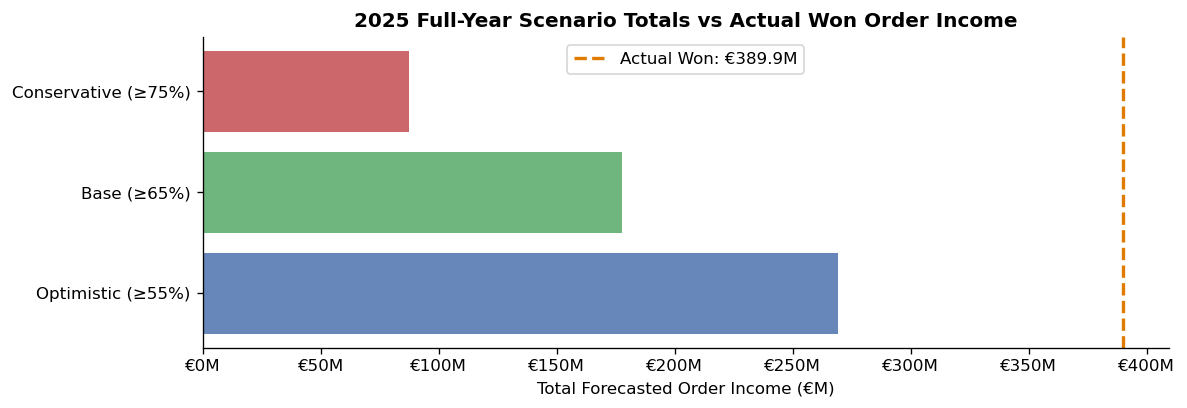

,Forecasted (€),Actual Won (€),Error (€),Error (%)
Scenario,,,,
Optimistic (≥55%),"€269,041,969","€389,909,427","€-120,867,458",-31.0%
Base (≥65%),"€177,709,042","€389,909,427","€-212,200,384",-54.4%
Conservative (≥75%),"€87,471,922","€389,909,427","€-302,437,505",-77.6%


In [390]:
# ── SCENARIO ACCURACY COMPARISON ─────────────────────────────────────────────
scenario_totals = {
    f'Optimistic (\u2265{P1_THRESHOLD_OPT:.0%})':    stitched_opt.sum(),
    f'Base (\u2265{P1_THRESHOLD_BASE:.0%})':          stitched_base.sum(),
    f'Conservative (\u2265{P1_THRESHOLD_CONS:.0%})':  stitched_cons.sum(),
}
actual_total = actual_monthly.sum()

sc_labels    = list(scenario_totals.keys())
sc_values    = list(scenario_totals.values())
sc_colors    = [COLORS['Optimistic'], COLORS['Base'], COLORS['Conservative']]

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.barh(sc_labels, [v / 1e6 for v in sc_values], color=sc_colors, alpha=0.85)
ax.axvline(actual_total / 1e6, color=COLORS['Actual'], lw=2, ls='--',
           label=f'Actual Won: \u20ac{actual_total / 1e6:.1f}M')
ax.set_xlabel('Total Forecasted Order Income (\u20acM)')
ax.set_title('2025 Full-Year Scenario Totals vs Actual Won Order Income', fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'\u20ac{v:.0f}M'))
ax.legend()
plt.tight_layout()
plt.show()

sc_rows = []
for name, fc in scenario_totals.items():
    err = fc - actual_total
    sc_rows.append({
        'Scenario':        name,
        'Forecasted (\u20ac)':   fc,
        'Actual Won (\u20ac)':   actual_total,
        'Error (\u20ac)':        err,
        'Error (%)':       err / actual_total * 100 if actual_total > 0 else np.nan,
    })
sc_df = pd.DataFrame(sc_rows).set_index('Scenario')
display(
    sc_df.style
    .format({
        'Forecasted (\u20ac)':  '\u20ac{:,.0f}',
        'Actual Won (\u20ac)':  '\u20ac{:,.0f}',
        'Error (\u20ac)':       '\u20ac{:+,.0f}',
        'Error (%)':       '{:+.1f}%',
    })
    .set_caption('Scenario Accuracy \u2014 2025 Full Year')
)

In [391]:
# ── DEAL-LEVEL OUTCOME TRACKING (Base Scenario, all 4 quarters) ─────────────
forecast_ids = set(pd.concat([r['df_base'] for r in all_results_2025])['chance_id'])
actual_ids   = set(df_actual['chance_id'])
snap_ids     = set(pd.concat([r['df_all']  for r in all_results_2025])['chance_id'])
# Note: r['df_all'] contains deals whose AFT-predicted close date fell in the
# quarter window — not ALL open deals. FN-B here means 'won but never forecast
# to close in any 2025 quarter' (may include deals with >2025 predicted dates).

tp_ids   = forecast_ids & actual_ids                   # predicted win → actually won
fp_ids   = forecast_ids - actual_ids                   # predicted win → did NOT win
fn_a_ids = (snap_ids - forecast_ids) & actual_ids      # in pipeline, below threshold → won
fn_b_ids = actual_ids - snap_ids                       # won, but never in any snapshot

all_base_df = pd.concat([r['df_base'] for r in all_results_2025]).drop_duplicates('chance_id')

tp_rev   = all_base_df[all_base_df['chance_id'].isin(tp_ids)]['forecasted_amount'].sum()
fp_rev   = all_base_df[all_base_df['chance_id'].isin(fp_ids)]['forecasted_amount'].sum()
fn_a_rev = df_actual[df_actual['chance_id'].isin(fn_a_ids)]['amount'].sum()
fn_b_rev = df_actual[df_actual['chance_id'].isin(fn_b_ids)]['amount'].sum()

outcome_df = pd.DataFrame([
    {'Outcome': 'True Positive  (forecast & won)',         'Deals': len(tp_ids),   'Order Income (€)': tp_rev,   'Note': 'Correctly predicted'},
    {'Outcome': 'False Positive (forecast, not won)',      'Deals': len(fp_ids),   'Order Income (€)': fp_rev,   'Note': 'Over-stated in forecast'},
    {'Outcome': 'False Negative A (in pipeline, missed)',  'Deals': len(fn_a_ids), 'Order Income (€)': fn_a_rev, 'Note': 'Below threshold → won (threshold miss)'},
    {'Outcome': 'False Negative B (structural gap)',       'Deals': len(fn_b_ids), 'Order Income (€)': fn_b_rev, 'Note': 'Not forecast to close in any 2025 quarter window'},
]).set_index('Outcome')

print('Deal-Level Outcome Breakdown — Base Scenario (all 4 quarters)')
display(
    outcome_df.style
    .format({'Order Income (€)': '€{:,.0f}'})
    .set_caption('Outcome Classification: TP / FP / FN-A / FN-B')
)

# Top 10 False Positives
fp_table = (
    all_base_df[all_base_df['chance_id'].isin(fp_ids)]
    .nlargest(10, 'forecasted_amount')
    [['chance_id', 'amount', 'probability', 'predicted_close_date', 'forecasted_amount']]
    .reset_index(drop=True)
)
display(
    fp_table.style
    .format({'amount': '€{:,.0f}', 'forecasted_amount': '€{:,.0f}', 'probability': '{:.0%}'})
    .set_caption(f'Top 10 False Positives — highest value deals that did not close ({len(fp_ids)} total)')
    .hide(axis='index')
)

Deal-Level Outcome Breakdown — Base Scenario (all 4 quarters)


,Deals,Order Income (€),Note
Outcome,,,
True Positive (forecast & won),494,"€90,945,221",Correctly predicted
"False Positive (forecast, not won)",414,"€52,103,294",Over-stated in forecast
"False Negative A (in pipeline, missed)",544,"€57,750,905",Below threshold → won (threshold miss)
False Negative B (structural gap),1465,"€245,230,323",Not forecast to close in any 2025 quarter window


chance_id,amount,probability,predicted_close_date,forecasted_amount
9bcd13f0e24175cc,"€6,444,061",69%,2025-10-08 00:00:00,"€6,444,061"
aafef84206df1ea5,"€5,891,581",92%,2025-02-15 12:59:07,"€5,891,581"
4e5bddbeea7b1996,"€4,967,197",91%,2025-01-08 00:00:00,"€4,967,197"
4cc29d62c95a6317,"€3,684,003",74%,2025-01-08 00:00:00,"€3,684,003"
3ccf651d218e9851,"€2,048,531",71%,2025-07-08 00:00:00,"€2,048,531"
8fd2978d9d0a4aba,"€1,412,484",79%,2025-03-24 16:10:56,"€1,412,484"
4c3179a4f0939cf3,"€1,240,691",67%,2025-12-12 10:58:23,"€1,240,691"
5bd6a015ca504d01,"€1,142,517",76%,2025-06-12 21:09:33,"€1,142,517"
e02ea23199c9a628,"€1,105,793",66%,2025-04-25 09:57:50,"€1,105,793"
93c781fa04289de9,"€1,063,051",67%,2025-04-08 00:00:00,"€1,063,051"


---

## Part 2c — Monthly 2025 Forecast

Each of the 12 months in 2025 is forecast from its own snapshot (built in Part 0). This gives
a more granular view than the quarterly forecasts: each snapshot reflects the pipeline as it
stood at the start of that month. The Base forecast is compared directly against the actual
monthly won order income from Part 2b.


In [392]:
# ── PART 2c CONFIGURATION ───────────────────────────────────────────
# MONTHS_2025 is defined in Part 1. Load the pre-built monthly XGBoost snapshots.
snapshots_monthly_2025 = {
    m['snapshot']: pd.read_parquet(
        f'../data/RQ3 Predictions/forecast_{m["snapshot"]}.parquet'
    )
    for m in MONTHS_2025
}
print('Monthly XGBoost snapshots loaded:')
for snap_lbl, sdf in snapshots_monthly_2025.items():
    print(f'  {snap_lbl}: {len(sdf):,} open deals')


Monthly XGBoost snapshots loaded:
  2025-01-01: 1,717 open deals
  2025-02-01: 1,689 open deals
  2025-03-01: 1,752 open deals
  2025-04-01: 1,823 open deals
  2025-05-01: 1,841 open deals
  2025-06-01: 1,868 open deals
  2025-07-01: 1,840 open deals
  2025-08-01: 1,858 open deals
  2025-09-01: 1,905 open deals
  2025-10-01: 1,933 open deals
  2025-11-01: 1,866 open deals
  2025-12-01: 1,826 open deals


,Deals (Base),Optimistic (€),Base (€),Conservative (€)
Month,,,,
2025-01,219,"€45,941,884","€23,297,713","€13,558,554"
2025-02,174,"€39,989,821","€14,329,853","€4,311,581"
2025-03,176,"€21,332,209","€12,722,468","€6,415,779"
2025-04,196,"€44,792,971","€30,194,216","€7,247,868"
2025-05,211,"€38,896,552","€29,697,304","€6,463,927"
2025-06,228,"€59,300,407","€35,838,821","€11,296,350"
2025-07,196,"€54,105,821","€37,609,907","€17,250,807"
2025-08,177,"€64,579,847","€49,150,015","€13,242,029"
2025-09,190,"€73,053,221","€50,913,081","€15,517,823"


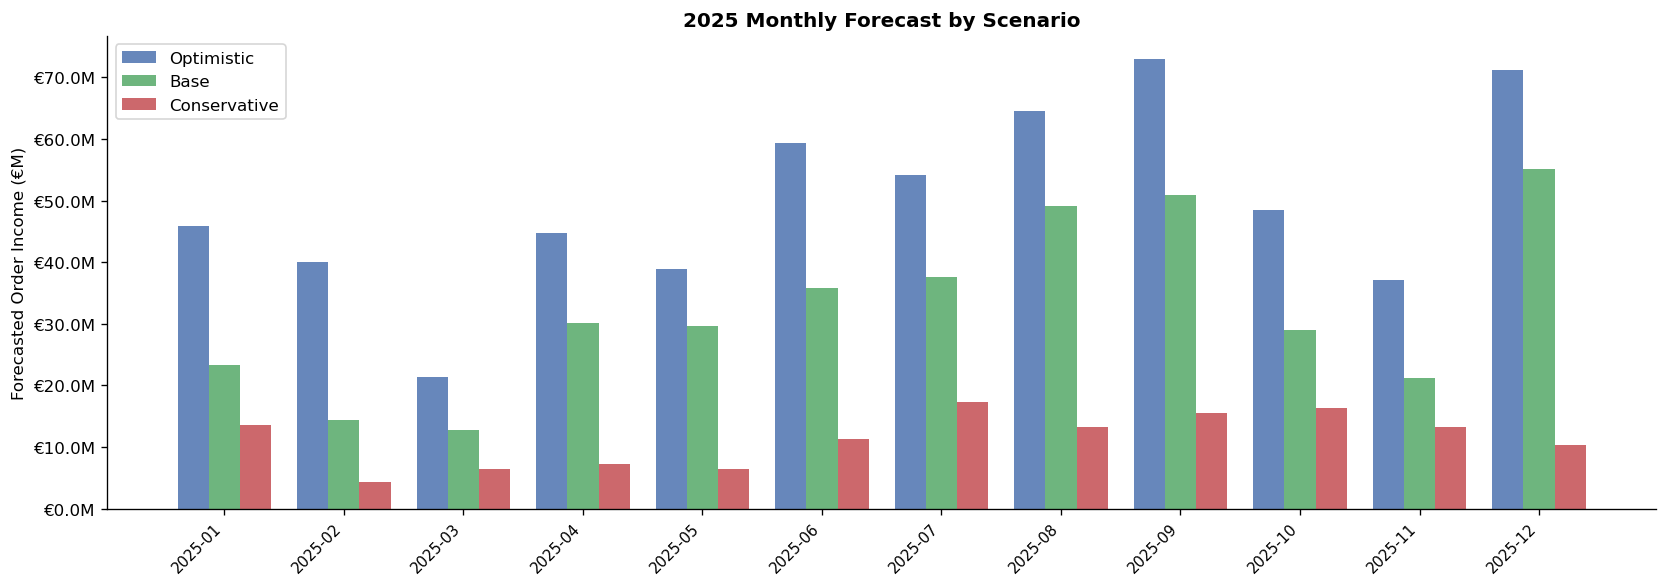

In [393]:
# ── Monthly forecast loop ────────────────────────────────────────────────────
_monthly_rows = []
_m_opt_vals, _m_base_vals, _m_cons_vals = [], [], []

# ── TP/FP tracking sets (accumulated across all 12 months) ───────────────────
_m_tp_ids, _m_fp_ids, _m_fna_ids = set(), set(), set()
_m_all_snap_ids   = set()     # all deals visible in ANY monthly snapshot
_m_all_base_parts = []        # for revenue look-ups

for m in MONTHS_2025:
    sdf = snapshots_monthly_2025[m['snapshot']].copy()
    sdf = sdf.rename(columns={
        'xgb_prob_won':  'probability',
        'closedate':     'predicted_close_date',
        'updated_dt':    'last_update_date',
        'registered_dt': 'deal_open_date',
    })
    sdf['predicted_close_date'] = pd.to_datetime(sdf['predicted_close_date'])

    # Accumulate all open deals across snapshots (for FN-B)
    _m_all_snap_ids |= set(sdf['chance_id'])

    # Filter to deals closing in this specific month
    m_start = pd.Timestamp(m['start'])
    m_end   = m_start + pd.offsets.MonthEnd(0)
    df_m    = sdf[(sdf['predicted_close_date'] >= m_start) &
                  (sdf['predicted_close_date'] <= m_end)].copy()

    df_opt  = apply_scenario(df_m, P1_THRESHOLD_OPT,  P1_SAFETY_BUFFER)
    df_base = apply_scenario(df_m, P1_THRESHOLD_BASE, P1_SAFETY_BUFFER)
    df_cons = apply_scenario(df_m, P1_THRESHOLD_CONS, P1_SAFETY_BUFFER)

    # ── TP/FP accumulation ────────────────────────────────────────────────────
    _act_m    = set(df_actual[df_actual['month'] == pd.Period(m['label'], 'M')]['chance_id'])
    _fcast_m  = set(df_base['chance_id'])
    _snap_m   = set(df_m['chance_id'])
    _m_tp_ids  |= _fcast_m & _act_m
    _m_fp_ids  |= _fcast_m - _act_m
    _m_fna_ids |= (_snap_m - _fcast_m) & _act_m
    if not df_base.empty:
        _m_all_base_parts.append(df_base)

    rev_opt  = df_opt['forecasted_amount'].sum()
    rev_base = df_base['forecasted_amount'].sum()
    rev_cons = df_cons['forecasted_amount'].sum()

    _m_opt_vals.append(rev_opt)
    _m_base_vals.append(rev_base)
    _m_cons_vals.append(rev_cons)
    _monthly_rows.append({
        'Month':            m['label'],
        'Deals (Base)':     len(df_base),
        'Optimistic (\u20ac)': rev_opt,
        'Base (\u20ac)':       rev_base,
        'Conservative (\u20ac)': rev_cons,
    })

# FN-B: actually won in 2025 but never appeared in any monthly snapshot
_m_fnb_ids = set(df_actual['chance_id']) - _m_all_snap_ids
_m_all_base_df = (
    pd.concat(_m_all_base_parts).drop_duplicates('chance_id')
    if _m_all_base_parts
    else pd.DataFrame(columns=['chance_id', 'forecasted_amount'])
)

_monthly_tbl = pd.DataFrame(_monthly_rows).set_index('Month')
display(
    _monthly_tbl.style
    .format({
        'Deals (Base)': '{:,}',
        'Optimistic (\u20ac)': '\u20ac{:,.0f}',
        'Base (\u20ac)': '\u20ac{:,.0f}',
        'Conservative (\u20ac)': '\u20ac{:,.0f}',
    })
    .set_caption('2025 Monthly Forecast by Scenario (Base threshold \u2265 65%)')
)

# ── 12-month bar chart ────────────────────────────────────────────────────────
_x     = np.arange(12)
_width = 0.26
_month_labels = [m['label'] for m in MONTHS_2025]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(_x - _width, [v / 1e6 for v in _m_opt_vals],  _width,
       label='Optimistic',   color=COLORS['Optimistic'],   alpha=0.85)
ax.bar(_x,           [v / 1e6 for v in _m_base_vals], _width,
       label='Base',          color=COLORS['Base'],          alpha=0.85)
ax.bar(_x + _width, [v / 1e6 for v in _m_cons_vals], _width,
       label='Conservative', color=COLORS['Conservative'], alpha=0.85)
ax.set_xticks(_x)
ax.set_xticklabels(_month_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Forecasted Order Income (\u20acM)')
ax.set_title('2025 Monthly Forecast by Scenario', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'\u20ac{v:.1f}M'))
ax.legend()
plt.tight_layout()
plt.show()


── Accuracy Summary — Monthly Snapshots, Base Scenario ──────
  MAE (monthly avg)  :  €  13,490,176
  MAPE (monthly avg) :        44.6%
  Total Base Forecast:  € 389,061,294
  Total Actual Won   :  € 389,909,427
  Total Error        :  €    -848,132



,Base Forecast (€),Actual Won (€),Error (€),Abs Error (€),MAPE (%)
Month,,,,,
2025-01,"€23,297,713","€15,704,027","€+7,593,687","€7,593,687",48.4%
2025-02,"€14,329,853","€14,557,536","€-227,683","€227,683",1.6%
2025-03,"€12,722,468","€40,456,095","€-27,733,628","€27,733,628",68.6%
2025-04,"€30,194,216","€13,898,997","€+16,295,218","€16,295,218",117.2%
2025-05,"€29,697,304","€29,779,547","€-82,242","€82,242",0.3%
2025-06,"€35,838,821","€19,041,787","€+16,797,034","€16,797,034",88.2%
2025-07,"€37,609,907","€40,621,603","€-3,011,696","€3,011,696",7.4%
2025-08,"€49,150,015","€32,301,355","€+16,848,660","€16,848,660",52.2%
2025-09,"€50,913,081","€47,625,354","€+3,287,727","€3,287,727",6.9%


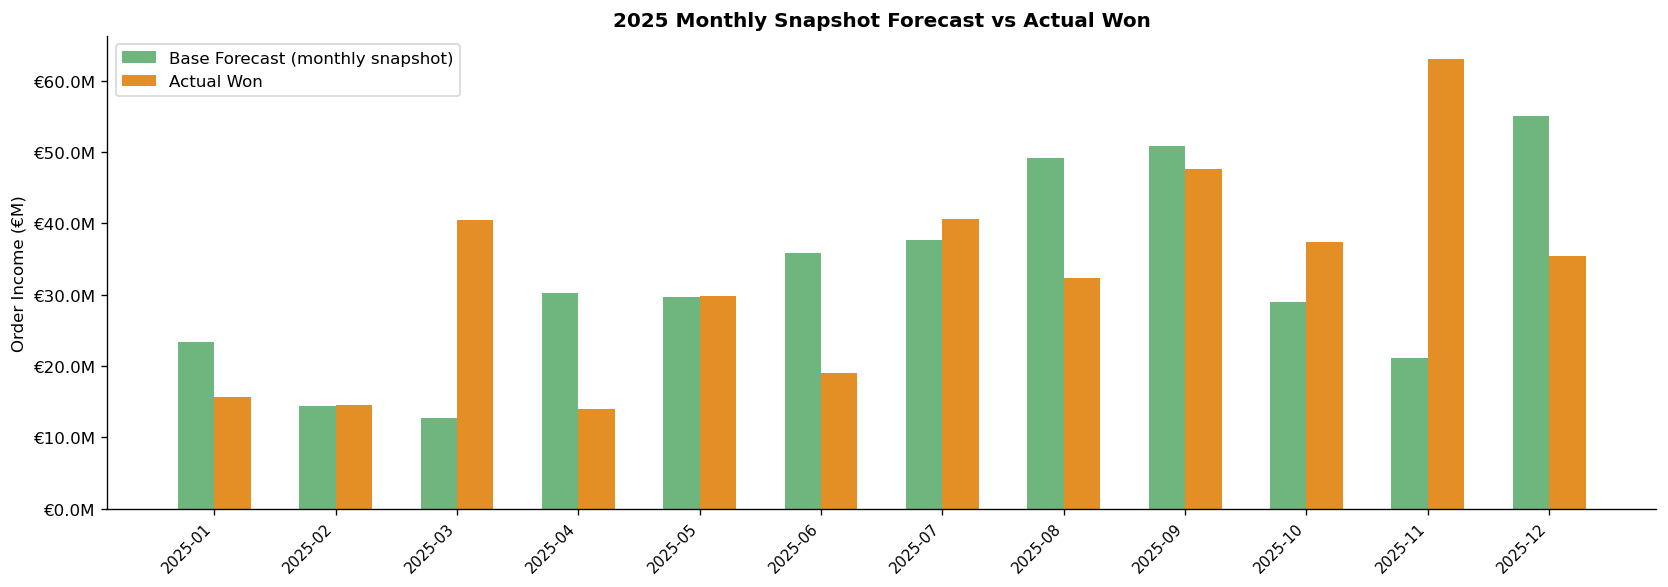

In [394]:
# ── Monthly forecast vs actuals ───────────────────────────────────────────────
# actual_monthly and _all_months_2025 are defined in Part 1 (Naive Baseline setup).
# _all_months_2025 is defined in Part 1 (Naive Baseline setup).
_m2b_base_series = pd.Series(
    _m_base_vals,
    index=_all_months_2025,
    name='Base Forecast',
)

_acc2b = pd.DataFrame({
    'Month':                [str(m) for m in _all_months_2025],
    'Base Forecast (€)':    _m2b_base_series.values,
    'Actual Won (€)':       actual_monthly.reindex(_all_months_2025, fill_value=0).values,
}).set_index('Month')
_acc2b['Error (€)']     = _acc2b['Base Forecast (€)'] - _acc2b['Actual Won (€)']
_acc2b['Abs Error (€)'] = _acc2b['Error (€)'].abs()
_acc2b['MAPE (%)']       = (
    _acc2b['Abs Error (€)'] / _acc2b['Actual Won (€)'].replace(0, float('nan')) * 100
).round(1)

_mae2b      = _acc2b['Abs Error (€)'].mean()
_mape2b     = _acc2b['MAPE (%)'].mean()
_fc_tot2b   = _acc2b['Base Forecast (€)'].sum()
_act_tot2b  = _acc2b['Actual Won (€)'].sum()
_err_tot2b  = _fc_tot2b - _act_tot2b

print('── Accuracy Summary — Monthly Snapshots, Base Scenario ──────')
print(f'  MAE (monthly avg)  :  €{_mae2b:>12,.0f}')
print(f'  MAPE (monthly avg) :  {_mape2b:>10.1f}%')
print(f'  Total Base Forecast:  €{_fc_tot2b:>12,.0f}')
print(f'  Total Actual Won   :  €{_act_tot2b:>12,.0f}')
print(f'  Total Error        :  €{_err_tot2b:>+12,.0f}')
print()

display(
    _acc2b.style
    .format({
        'Base Forecast (€)': '€{:,.0f}',
        'Actual Won (€)':    '€{:,.0f}',
        'Error (€)':         '€{:+,.0f}',
        'Abs Error (€)':     '€{:,.0f}',
        'MAPE (%)':          '{:.1f}%',
    })
    .set_caption('Monthly Accuracy — Monthly Snapshot Forecast vs Actual Won')
)

# ── Comparison chart ──────────────────────────────────────────────────────────
_x2 = np.arange(12)
_w2 = 0.30
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(_x2 - _w2/2, _m2b_base_series.values / 1e6, _w2,
       label='Base Forecast (monthly snapshot)', color=COLORS['Base'],   alpha=0.85)
ax.bar(_x2 + _w2/2, actual_monthly.reindex(_all_months_2025, fill_value=0).values / 1e6, _w2,
       label='Actual Won',                       color=COLORS['Actual'], alpha=0.85)
ax.set_xticks(_x2)
ax.set_xticklabels([str(m) for m in _all_months_2025], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Order Income (€M)')
ax.set_title('2025 Monthly Snapshot Forecast vs Actual Won', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'€{v:.1f}M'))
ax.legend()
plt.tight_layout()
plt.show()


In [395]:
# ── DEAL-LEVEL OUTCOME TRACKING — Monthly Forecast (Base Scenario) ───────────
# Uses sets accumulated in the monthly loop above.

_m_tp_rev   = _m_all_base_df[_m_all_base_df['chance_id'].isin(_m_tp_ids)]['forecasted_amount'].sum()
_m_fp_rev   = _m_all_base_df[_m_all_base_df['chance_id'].isin(_m_fp_ids)]['forecasted_amount'].sum()
_m_fna_rev  = df_actual[df_actual['chance_id'].isin(_m_fna_ids)]['amount'].sum()
_m_fnb_rev  = df_actual[df_actual['chance_id'].isin(_m_fnb_ids)]['amount'].sum()

_m_outcome_df = pd.DataFrame([
    {'Outcome': 'True Positive  (forecast & won)',         'Deals': len(_m_tp_ids),  'Order Income (\u20ac)': _m_tp_rev,  'Note': 'Correctly predicted'},
    {'Outcome': 'False Positive (forecast, not won)',      'Deals': len(_m_fp_ids),  'Order Income (\u20ac)': _m_fp_rev,  'Note': 'Over-stated in forecast'},
    {'Outcome': 'False Negative A (in pipeline, missed)',  'Deals': len(_m_fna_ids), 'Order Income (\u20ac)': _m_fna_rev, 'Note': 'Below threshold \u2192 won (threshold miss)'},
    {'Outcome': 'False Negative B (structural gap)',       'Deals': len(_m_fnb_ids), 'Order Income (\u20ac)': _m_fnb_rev, 'Note': 'Not in pipeline at forecast time'},
]).set_index('Outcome')

print('Deal-Level Outcome Breakdown \u2014 Monthly Forecast, Base Scenario (all 12 months)')
display(
    _m_outcome_df.style
    .format({'Order Income (\u20ac)': '\u20ac{:,.0f}'})
    .set_caption('Outcome Classification: TP / FP / FN-A / FN-B (Monthly Forecast)')
)

# Top 10 False Positives (monthly)
_m_fp_table = (
    _m_all_base_df[_m_all_base_df['chance_id'].isin(_m_fp_ids)]
    .nlargest(10, 'forecasted_amount')
    [['chance_id', 'amount', 'probability', 'predicted_close_date', 'forecasted_amount']]
    .reset_index(drop=True)
)
display(
    _m_fp_table.style
    .format({'amount': '\u20ac{:,.0f}', 'forecasted_amount': '\u20ac{:,.0f}', 'probability': '{:.0%}'})
    .set_caption(f'Top 10 False Positives \u2014 Monthly Forecast ({len(_m_fp_ids)} total)')
    .hide(axis='index')
)


Deal-Level Outcome Breakdown — Monthly Forecast, Base Scenario (all 12 months)


,Deals,Order Income (€),Note
Outcome,,,
True Positive (forecast & won),452,"€71,994,418",Correctly predicted
"False Positive (forecast, not won)",764,"€142,951,478",Over-stated in forecast
"False Negative A (in pipeline, missed)",539,"€50,962,095",Below threshold → won (threshold miss)
False Negative B (structural gap),644,"€20,345,407",Not in pipeline at forecast time


chance_id,amount,probability,predicted_close_date,forecasted_amount
34e484394c391b01,"€35,111,607",71%,2025-12-08 00:00:00,"€35,111,607"
73153abcae95e7df,"€13,788,384",67%,2025-04-08 00:00:00,"€13,788,384"
9bcd13f0e24175cc,"€6,444,061",67%,2025-08-08 00:00:00,"€6,444,061"
83ed789e45032c29,"€5,036,971",82%,2025-07-08 00:00:00,"€5,036,971"
4e5bddbeea7b1996,"€4,967,197",91%,2025-01-08 00:00:00,"€4,967,197"
4cc29d62c95a6317,"€3,684,003",74%,2025-01-08 00:00:00,"€3,684,003"
0d2b728d7d8d57e0,"€2,961,926",69%,2025-12-08 00:00:00,"€2,961,926"
3ccf651d218e9851,"€2,042,830",69%,2025-06-08 00:00:00,"€2,042,830"
ec7f17fc83765066,"€1,747,633",83%,2025-09-27 08:52:31,"€1,747,633"
26b19aa0a21e785c,"€1,744,875",80%,2025-01-08 00:00:00,"€1,744,875"


---

# Part 3 — 2026 Live Forecast

Forward-looking Q1 2026 forecast using the XGBoost snapshot from 2026-01-01.
Staleness is measured relative to today's date.


In [396]:
# ── PART 3 CONFIGURATION ─────────────────────────────────────────────────────
QUARTERS_2026 = [
    {'label': 'Q1 2026', 'start': '2026-01', 'end': '2026-03'},
]

P3_THRESHOLD_OPT  = 0.55
P3_THRESHOLD_BASE = 0.65
P3_THRESHOLD_CONS = 0.75
P3_SAFETY_BUFFER  = 0.0
P3_MAX_STALE_DAYS = 30
P3_MAX_SHIFTS     = 3

df_fc = pd.read_parquet('../data/RQ3 Predictions/forecast_2026-01-01.parquet')
df_fc = df_fc.rename(columns={
    'xgb_prob_won':  'probability',
    'closedate':     'predicted_close_date',
    'updated_dt':    'last_update_date',
    'registered_dt': 'deal_open_date',
})
df_fc['predicted_close_date'] = pd.to_datetime(df_fc['predicted_close_date'])
df_fc['last_update_date']     = pd.to_datetime(df_fc['last_update_date'])
df_fc['deal_open_date']       = pd.to_datetime(df_fc['deal_open_date'])

q_s = pd.Timestamp('2026-01')
q_e = pd.Timestamp('2026-03') + pd.offsets.MonthEnd(0)
n_q1 = ((df_fc['predicted_close_date'] >= q_s) & (df_fc['predicted_close_date'] <= q_e)).sum()

print(f'Loaded {len(df_fc):,} open opportunities (snapshot 2026-01-01, AFT close dates)')
print(f'Probability range : {df_fc["probability"].min():.2f} – {df_fc["probability"].max():.2f}')
print(f'Q1 2026 window    : {n_q1:,} deals (Jan–Mar 2026)')

Loaded 1,759 open opportunities (snapshot 2026-01-01, AFT close dates)
Probability range : 0.01 – 0.95
Q1 2026 window    : 1,333 deals (Jan–Mar 2026)


In [397]:
def run_quarterly_forecast_2026(q: dict) -> dict:
    """
    Order Income forecast for one quarter using the pre-built 2026-01-01 XGBoost snapshot.
    Staleness is measured against today's date.
    """
    snap_ts  = pd.Timestamp('2026-01-01')
    q_start  = pd.Timestamp(q['start'])
    q_end    = pd.Timestamp(q['end']) + pd.offsets.MonthEnd(0)

    df = df_fc[
        (df_fc['predicted_close_date'] >= q_start) &
        (df_fc['predicted_close_date'] <= q_end)
    ].copy()
    df['days_stale'] = (snap_ts - df['last_update_date']).dt.days

    df_opt  = apply_scenario(df, P3_THRESHOLD_OPT,  P3_SAFETY_BUFFER)
    df_base = apply_scenario(df, P3_THRESHOLD_BASE, P3_SAFETY_BUFFER)
    df_cons = apply_scenario(df, P3_THRESHOLD_CONS, P3_SAFETY_BUFFER)

    rev_opt  = monthly_revenue(df_opt,  q['start'], 3)
    rev_base = monthly_revenue(df_base, q['start'], 3)
    rev_cons = monthly_revenue(df_cons, q['start'], 3)
    months   = rev_base.index

    # ── Print summary ────────────────────────────────────────────────────────
    sep = '─' * 60
    print(sep)
    print(f'  {q["label"]}  |  snapshot 2026-01-01')
    print(sep)
    print(f'  Deals in window: {len(df):,}')
    if len(df) > 0:
        print(f'  Prob range     : {df["probability"].min():.2f} – {df["probability"].max():.2f}')
    print()
    for lbl, sdf in [('Optimistic', df_opt), ('Base', df_base), ('Conservative', df_cons)]:
        print(f'  {lbl:14s}: {len(sdf):>3d} deals  |  €{sdf["forecasted_amount"].sum():>12,.0f}')
    print()

    # Monthly forecast table
    tbl = pd.DataFrame({
        'Month':            [str(m) for m in months],
        'Opt Deals':        [(df_opt['predicted_close_date'].dt.to_period('M') == m).sum() for m in months],
        'Base Deals':       [(df_base['predicted_close_date'].dt.to_period('M') == m).sum() for m in months],
        'Cons Deals':       [(df_cons['predicted_close_date'].dt.to_period('M') == m).sum() for m in months],
        'Optimistic (€)':  rev_opt.values,
        'Base (€)':         rev_base.values,
        'Conservative (€)': rev_cons.values,
    }).set_index('Month')
    display(
        tbl.style
        .format({'Optimistic (€)': '€{:,.0f}', 'Base (€)': '€{:,.0f}', 'Conservative (€)': '€{:,.0f}'})
        .set_caption(f'{q["label"]} — Monthly Forecast')
    )

    # Bar chart
    if len(df) > 0:
        x, width = np.arange(3), 0.26
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.bar(x - width, rev_opt.values  / 1e6, width, label='Optimistic',   color=COLORS['Optimistic'],   alpha=0.85)
        ax.bar(x,         rev_base.values / 1e6, width, label='Base',          color=COLORS['Base'],          alpha=0.85)
        ax.bar(x + width, rev_cons.values / 1e6, width, label='Conservative', color=COLORS['Conservative'], alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels([str(m) for m in months], fontsize=10)
        ax.set_ylabel('Forecasted Order Income (€M)')
        ax.set_title(f'{q["label"]} — Monthly Order Income by Scenario', fontweight='bold')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'€{v:.1f}M'))
        ax.legend()
        plt.tight_layout()
        plt.show()

    # Segment breakdown (Base)
    if len(df_base) > 0:
        seg = apply_bu_labels(segment_summary(df_base, 'business_unit'))
        fig2, ax2 = plt.subplots(figsize=(10, max(3, len(seg) * 0.55)))
        ax2.barh(seg['business_unit'], seg['total_revenue'] / 1e6, color=COLORS['Base'], alpha=0.85)
        ax2.set_xlabel('Forecasted Order Income (€M)')
        ax2.set_title(f'{q["label"]} — Base Order Income by Business Unit', fontweight='bold')
        ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'€{v:.1f}M'))
        ax2.invert_yaxis()
        plt.tight_layout()
        plt.show()
        display(
            seg.style
            .format({'total_revenue': '€{:,.0f}', 'avg_deal_size': '€{:,.0f}', 'revenue_share_%': '{:.1f}%'})
            .hide(axis='index')
            .set_caption(f'{q["label"]} — Base Order Income by Business Unit')
        )

    # Deals at risk (Base)
    df_risk = df_base[
        (df_base['close_date_shift'] > P3_MAX_SHIFTS) |
        (df_base['days_stale'] > P3_MAX_STALE_DAYS)
    ].copy()

    if len(df_risk) > 0:
        def _reasons(row):
            r = []
            if row['close_date_shift'] > P3_MAX_SHIFTS:
                r.append(f'Date pushed {row["close_date_shift"]}x')
            if row['days_stale'] > P3_MAX_STALE_DAYS:
                r.append(f'No update for {int(row["days_stale"])} days')
            return ' | '.join(r)
        df_risk['risk_reasons'] = df_risk.apply(_reasons, axis=1)

        risk_cols = ['chance_id', 'amount', 'probability', 'predicted_close_date',
                     'close_date_shift', 'last_update_date', 'risk_reasons']
        df_risk_sorted = df_risk[risk_cols].sort_values('amount', ascending=False).reset_index(drop=True)
        n_risk = len(df_risk_sorted)
        print(f'  Deals at risk: {n_risk} of {len(df_base)} Base deals  |  €{df_risk["forecasted_amount"].sum():,.0f}')
        display(
            df_risk_sorted.head(10).style
            .format({'amount': '€{:,.0f}', 'probability': '{:.0%}'})
            .set_caption(f'{q["label"]} — Top 10 of {n_risk} Deals at Risk (Base Scenario)')
            .hide(axis='index')
        )
    else:
        print(f'  No deals at risk for {q["label"]}.')
    print()

    return {
        'label':    q['label'],
        'rev_opt':  rev_opt,
        'rev_base': rev_base,
        'rev_cons': rev_cons,
        'df_opt':   df_opt,
        'df_base':  df_base,
        'df_cons':  df_cons,
        'df_all':   df,
    }

────────────────────────────────────────────────────────────
  Q1 2026  |  snapshot 2026-01-01
────────────────────────────────────────────────────────────
  Deals in window: 1,333
  Prob range     : 0.01 – 0.95

  Optimistic    : 381 deals  |  € 125,545,175
  Base          : 274 deals  |  € 112,799,450
  Conservative  : 112 deals  |  €   8,437,530



,Opt Deals,Base Deals,Cons Deals,Optimistic (€),Base (€),Conservative (€)
Month,,,,,,
2026-01,268,193,83,"€117,280,702","€106,098,833","€6,212,792"
2026-02,75,53,20,"€5,813,063","€4,607,464","€1,391,684"
2026-03,38,28,9,"€2,451,410","€2,093,154","€833,054"


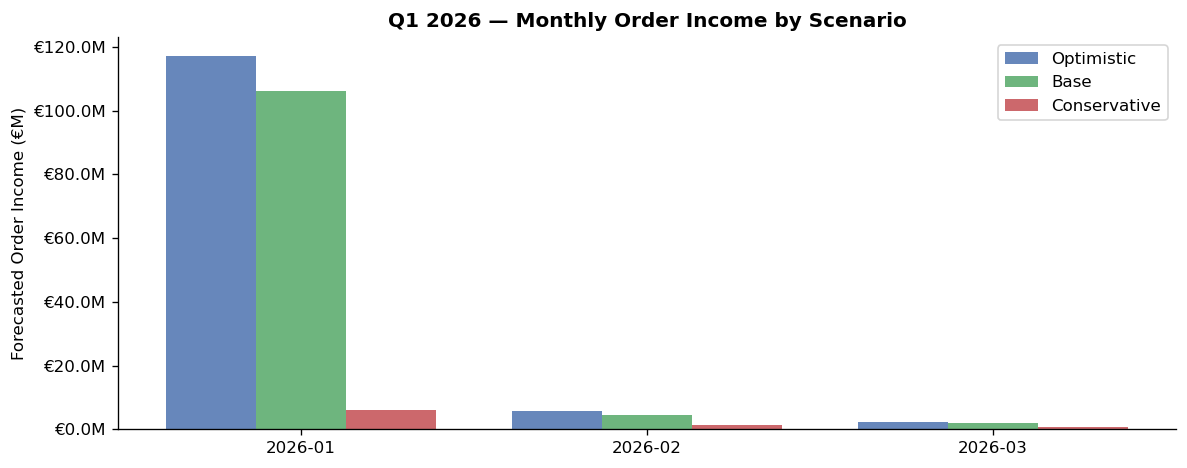

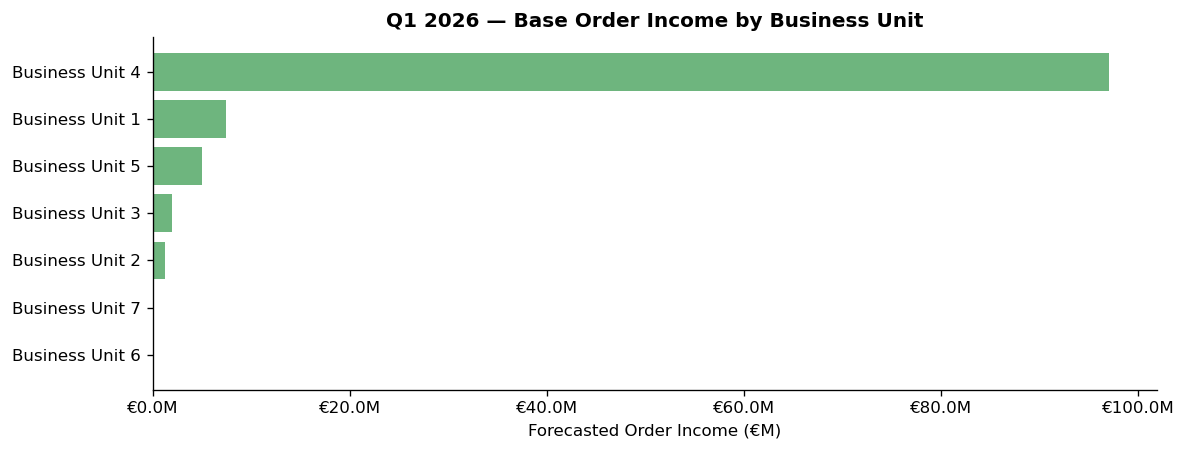

business_unit,total_revenue,deal_count,avg_deal_size,revenue_share_%
Business Unit 4,"€97,037,551",72,"€1,347,744",86.0%
Business Unit 1,"€7,403,442",131,"€56,515",6.6%
Business Unit 5,"€5,026,960",15,"€335,131",4.5%
Business Unit 3,"€2,024,617",24,"€84,359",1.8%
Business Unit 2,"€1,275,282",26,"€49,049",1.1%
Business Unit 7,"€31,599",6,"€5,266",0.0%
Business Unit 6,€0,0,€,0.0%


  Deals at risk: 111 of 274 Base deals  |  €40,709,050


chance_id,amount,probability,predicted_close_date,close_date_shift,last_update_date,risk_reasons
34e484394c391b01,"€35,111,607",71%,2026-01-08 00:00:00,5,2025-11-13 12:56:28,Date pushed 5x | No update for 48 days
3ccf651d218e9851,"€2,048,531",66%,2026-01-08 00:00:00,15,2025-12-18 08:26:53,Date pushed 15x
8dcfc856b15da0d5,"€644,864",83%,2026-01-28 16:26:00,1,2025-11-03 08:44:30,No update for 58 days
27b75a9c99496eaa,"€193,236",69%,2026-01-08 00:00:00,3,2025-11-21 05:38:51,No update for 40 days
951f353681e03f43,"€152,539",73%,2026-01-08 00:00:00,5,2025-12-15 16:11:33,Date pushed 5x
3b4a44c406276e2c,"€144,683",83%,2026-01-08 00:00:00,8,2025-12-18 11:49:24,Date pushed 8x
ba0e174a79da9d61,"€144,647",72%,2026-01-08 00:00:00,1,2025-11-26 11:33:54,No update for 35 days
6616fc476f674cfb,"€116,071",68%,2026-02-10 08:57:01,0,2025-10-30 10:41:38,No update for 62 days
3c4e068bbcf95db8,"€88,624",80%,2026-02-27 23:27:20,0,2025-11-17 16:30:59,No update for 44 days
bfc69ea6ac7b875d,"€75,462",81%,2026-01-08 00:00:00,1,2025-06-12 06:42:08,No update for 202 days



Q1 2026 totals by scenario:
────────────────────────────────────────
  Optimistic    : €   125,545,175
  Base          : €   112,799,450
  Conservative  : €     8,437,530


In [398]:
# ── Q1 2026 SUMMARY ──────────────────────────────────────────────────────────
q1_2026 = run_quarterly_forecast_2026(QUARTERS_2026[0])

print('Q1 2026 totals by scenario:')
print('─' * 40)
for lbl, key in [('Optimistic', 'rev_opt'), ('Base', 'rev_base'), ('Conservative', 'rev_cons')]:
    print(f'  {lbl:14s}: €{q1_2026[key].sum():>14,.0f}')

In [399]:
# ── Q1 2026 — Top 5 Projected Wins and Losses (Base Scenario) ────────────────
_df_all  = q1_2026['df_all'].copy()
_df_base = q1_2026['df_base'].copy()

_won_ids  = set(_df_base['chance_id'])
_df_lost  = _df_all[~_df_all['chance_id'].isin(_won_ids)].copy()

_cols = ['chance_id', 'amount', 'probability', 'predicted_close_date', 'business_unit']

_df_base = apply_bu_labels(_df_base)
_df_lost  = apply_bu_labels(_df_lost)

_top_won = (
    _df_base[_cols]
    .sort_values('amount', ascending=False)
    .head(5)
    .reset_index(drop=True)
)
_top_lost = (
    _df_lost[_cols]
    .sort_values('amount', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

display(
    _top_won.style
    .format({'amount': '€{:,.0f}', 'probability': '{:.0%}'})
    .set_caption('Top 5 Projected Wins — Q1 2026 (Base Scenario, by deal size)')
    .hide(axis='index')
)
display(
    _top_lost.style
    .format({'amount': '€{:,.0f}', 'probability': '{:.0%}'})
    .set_caption('Top 5 Projected Losses — Q1 2026 (below Base threshold, by deal size)')
    .hide(axis='index')
)


chance_id,amount,probability,predicted_close_date,business_unit
ec92462059631544,"€58,100,920",73%,2026-01-08 00:00:00,Business Unit 4
34e484394c391b01,"€35,111,607",71%,2026-01-08 00:00:00,Business Unit 4
3ccf651d218e9851,"€2,048,531",66%,2026-01-08 00:00:00,Business Unit 5
4124098e4b02f13b,"€1,791,748",73%,2026-02-09 17:17:49,Business Unit 5
387c9111e213c5fc,"€878,615",84%,2026-01-25 12:44:33,Business Unit 1


chance_id,amount,probability,predicted_close_date,business_unit
2db332b0946f30cf,"€45,888,537",18%,2026-01-08 00:00:00,Business Unit 4
9ac68fa8688e9087,"€14,621,079",12%,2026-01-08 00:00:00,Business Unit 4
9415553396c995f0,"€8,809,845",9%,2026-01-08 00:00:00,Business Unit 4
2475c265ae73a5d4,"€7,897,469",7%,2026-01-08 00:00:00,Business Unit 3
3578f02bf12adab1,"€4,447,346",25%,2026-01-05 09:29:38,Business Unit 5


---

# Part 4 — Probability-Weighted Approach

Instead of binary inclusion/exclusion by probability threshold, the **expected value** of
each deal is computed as `amount × probability`. Only deals with a win probability above
**25 %** are included (to filter out noise while keeping early-stage pipeline).

This produces a single weighted revenue estimate per month — no scenarios. Results are
compared against actual 2025 won deals, and a TP/FP/FN classification is provided using the
25 % threshold as the forecast inclusion criterion.


,Deals (> 55%),Expected Value (€),Actual Won (€),Delta (€)
Month,,,,
2025-01,300,"€31,733,015","€15,704,027","€+16,028,988"
2025-02,252,"€25,866,874","€14,557,536","€+11,309,338"
2025-03,246,"€15,119,408","€40,456,095","€-25,336,687"
2025-04,284,"€30,042,413","€13,898,997","€+16,143,416"
2025-05,280,"€27,321,675","€29,779,547","€-2,457,872"
2025-06,301,"€40,312,734","€19,041,787","€+21,270,947"
2025-07,277,"€39,013,533","€40,621,603","€-1,608,070"
2025-08,244,"€45,092,769","€32,301,355","€+12,791,414"
2025-09,260,"€50,827,447","€47,625,354","€+3,202,093"


── Accuracy Summary — Probability-Weighted, Base Scenario ──────
  MAE (monthly avg)    :  €  13,743,037
  MAPE (monthly avg)   :        53.1%
  Total Expected Value :  € 414,235,980
  Total Actual Won     :  € 389,909,427
  Total Delta          :  € +24,326,553



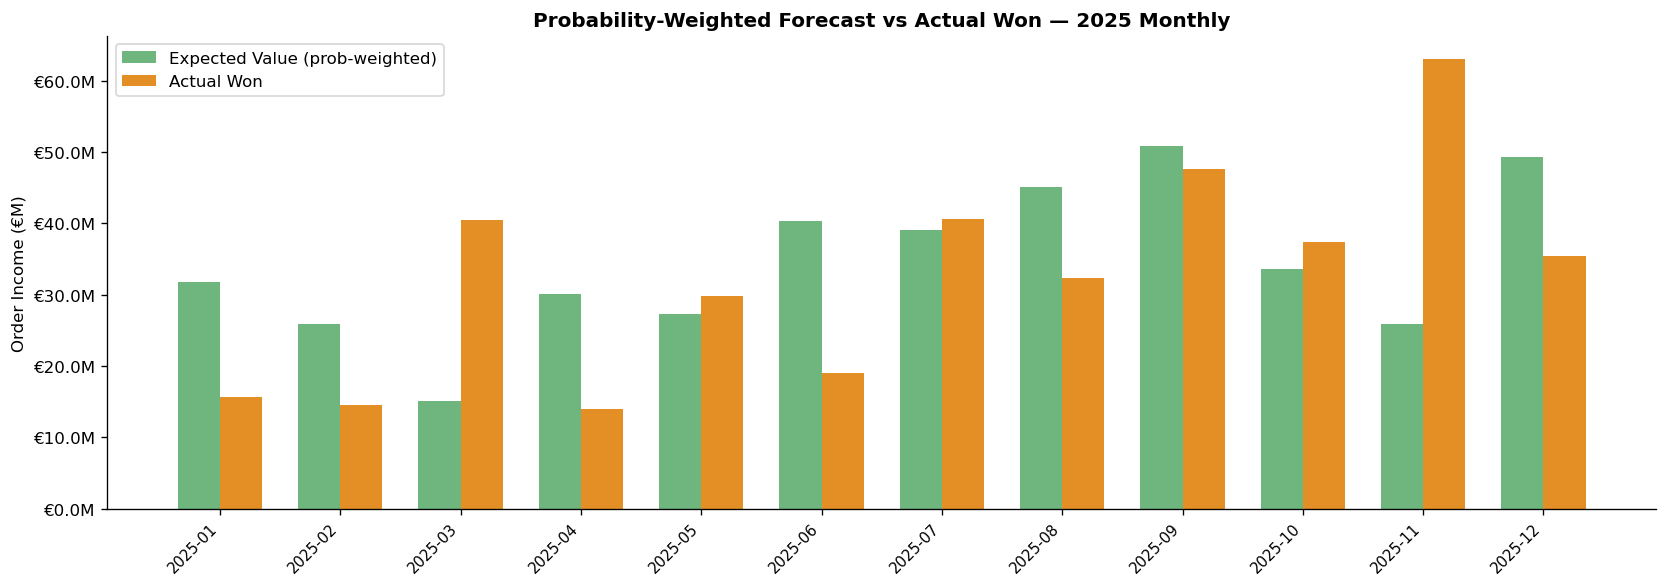

In [400]:
# ── Probability-Weighted Approach: monthly loop ────────────────────────────
PW_MIN_PROB = 0.55   # minimum probability to include a deal (user-specified: 55%)

_pw_rows = []

# TP/FP tracking (treat 'forecasted' = probability > PW_MIN_PROB)
_pw_tp_ids, _pw_fp_ids, _pw_fna_ids = set(), set(), set()
_pw_all_snap_ids   = set()
_pw_all_fcast_parts = []

for m in MONTHS_2025:
    sdf = snapshots_monthly_2025[m['snapshot']].copy()
    sdf = sdf.rename(columns={
        'xgb_prob_won':  'probability',
        'closedate':     'predicted_close_date',
        'updated_dt':    'last_update_date',
        'registered_dt': 'deal_open_date',
    })
    sdf['predicted_close_date'] = pd.to_datetime(sdf['predicted_close_date'])

    # Accumulate all snapshot deals for FN-B
    _pw_all_snap_ids |= set(sdf['chance_id'])

    # Filter to deals closing in this month
    m_start = pd.Timestamp(m['start'])
    m_end   = m_start + pd.offsets.MonthEnd(0)
    df_pw_m = sdf[
        (sdf['predicted_close_date'] >= m_start) &
        (sdf['predicted_close_date'] <= m_end)
    ].copy()

    # Include only deals above the minimum probability
    df_pw_inc = df_pw_m[df_pw_m['probability'] > PW_MIN_PROB].copy()
    df_pw_inc['expected_value'] = df_pw_inc['amount'] * df_pw_inc['probability']
    ev_total = df_pw_inc['expected_value'].sum()

    # ── TP/FP accumulation ──────────────────────────────────────────
    _act_m    = set(df_actual[df_actual['month'] == pd.Period(m['label'], 'M')]['chance_id'])
    _fcast_pw = set(df_pw_inc['chance_id'])
    _snap_pw  = set(df_pw_m['chance_id'])
    _pw_tp_ids  |= _fcast_pw & _act_m
    _pw_fp_ids  |= _fcast_pw - _act_m
    _pw_fna_ids |= (_snap_pw - _fcast_pw) & _act_m
    if not df_pw_inc.empty:
        _pw_all_fcast_parts.append(df_pw_inc)

    actual_m_rev = actual_monthly.get(pd.Period(m['label'], 'M'), 0)
    _pw_rows.append({
        'Month':              m['label'],
        'Deals (> 55%)':     len(df_pw_inc),
        'Expected Value (€)': ev_total,
        'Actual Won (€)':    actual_m_rev,
        'Delta (€)':         ev_total - actual_m_rev,
    })

# FN-B: won but never in any monthly snapshot
_pw_fnb_ids = set(df_actual['chance_id']) - _pw_all_snap_ids
_pw_all_fcast_df = (
    pd.concat(_pw_all_fcast_parts).drop_duplicates('chance_id')
    if _pw_all_fcast_parts
    else pd.DataFrame(columns=['chance_id', 'amount', 'probability', 'expected_value'])
)

_pw_tbl = pd.DataFrame(_pw_rows).set_index('Month')

display(
    _pw_tbl.style
    .format({
        'Deals (> 55%)':     '{:,}',
        'Expected Value (€)': '€{:,.0f}',
        'Actual Won (€)':    '€{:,.0f}',
        'Delta (€)':         '€{:+,.0f}',
    })
    .set_caption('Probability-Weighted Forecast — Monthly Expected Value vs Actual Won (deals > 55%)')
)

# ── Accuracy summary ─────────────────────────────────────────────
_pw_ev_total  = _pw_tbl['Expected Value (€)'].sum()
_pw_act_total = _pw_tbl['Actual Won (€)'].sum()
_pw_mae       = _pw_tbl['Delta (€)'].abs().mean()
_pw_mape      = (
    (_pw_tbl['Delta (€)'].abs() / _pw_tbl['Actual Won (€)'].replace(0, float('nan'))) * 100
).mean()

print('── Accuracy Summary — Probability-Weighted, Base Scenario ──────')
print(f'  MAE (monthly avg)    :  €{_pw_mae:>12,.0f}')
print(f'  MAPE (monthly avg)   :  {_pw_mape:>10.1f}%')
print(f'  Total Expected Value :  €{_pw_ev_total:>12,.0f}')
print(f'  Total Actual Won     :  €{_pw_act_total:>12,.0f}')
print(f'  Total Delta          :  €{_pw_ev_total - _pw_act_total:>+12,.0f}')
print()

# ── 12-month bar chart ────────────────────────────────────────────
_x_pw = np.arange(12)
_w_pw = 0.35
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(_x_pw - _w_pw / 2, _pw_tbl['Expected Value (€)'].values / 1e6, _w_pw,
       label='Expected Value (prob-weighted)', color=COLORS['Base'],   alpha=0.85)
ax.bar(_x_pw + _w_pw / 2, _pw_tbl['Actual Won (€)'].values / 1e6, _w_pw,
       label='Actual Won',                    color=COLORS['Actual'], alpha=0.85)
ax.set_xticks(_x_pw)
ax.set_xticklabels([m['label'] for m in MONTHS_2025], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Order Income (€M)')
ax.set_title('Probability-Weighted Forecast vs Actual Won — 2025 Monthly', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'€{v:.1f}M'))
ax.legend()
plt.tight_layout()
plt.show()


In [401]:
# ── Probability-Weighted: Outcome Classification ──────────────────────────
# 'Forecasted' = deal has probability > 25% (included in EV sum)

_pw_tp_rev  = _pw_all_fcast_df[_pw_all_fcast_df['chance_id'].isin(_pw_tp_ids)]['expected_value'].sum()
_pw_fp_ev   = _pw_all_fcast_df[_pw_all_fcast_df['chance_id'].isin(_pw_fp_ids)]['expected_value'].sum()
_pw_fna_rev = df_actual[df_actual['chance_id'].isin(_pw_fna_ids)]['amount'].sum()
_pw_fnb_rev = df_actual[df_actual['chance_id'].isin(_pw_fnb_ids)]['amount'].sum()

_pw_outcome = pd.DataFrame([
    {'Outcome': 'True Positive  (forecast & won)',         'Deals': len(_pw_tp_ids),  'Order Income / EV (€)': _pw_tp_rev,  'Note': 'Included (prob > 55%) → won'},
    {'Outcome': 'False Positive (forecast, not won)',      'Deals': len(_pw_fp_ids),  'Order Income / EV (€)': _pw_fp_ev,   'Note': 'Included (prob > 55%) → did not win'},
    {'Outcome': 'False Negative A (in pipeline, excluded)','Deals': len(_pw_fna_ids), 'Order Income / EV (€)': _pw_fna_rev, 'Note': 'Below 55% threshold → won (threshold miss)'},
    {'Outcome': 'False Negative B (structural gap)',       'Deals': len(_pw_fnb_ids), 'Order Income / EV (€)': _pw_fnb_rev, 'Note': 'Not in pipeline at forecast time'},
]).set_index('Outcome')

print('Deal-Level Outcome Breakdown — Probability-Weighted, > 55% inclusion (all 12 months)')
display(
    _pw_outcome.style
    .format({'Order Income / EV (€)': '€{:,.0f}'})
    .set_caption('Probability-Weighted — Outcome Classification: TP / FP / FN-A / FN-B')
)

# Top 10 False Positives by expected value
_pw_fp_table = (
    _pw_all_fcast_df[_pw_all_fcast_df['chance_id'].isin(_pw_fp_ids)]
    .nlargest(10, 'expected_value')
    [['chance_id', 'amount', 'probability', 'predicted_close_date', 'expected_value']]
    .reset_index(drop=True)
)
display(
    _pw_fp_table.style
    .format({'amount': '€{:,.0f}', 'expected_value': '€{:,.0f}', 'probability': '{:.0%}'})
    .set_caption(f'Probability-Weighted — Top 10 False Positives by Expected Value ({len(_pw_fp_ids)} total)')
    .hide(axis='index')
)


Deal-Level Outcome Breakdown — Probability-Weighted, > 55% inclusion (all 12 months)


,Deals,Order Income / EV (€),Note
Outcome,,,
True Positive (forecast & won),592,"€61,652,949",Included (prob > 55%) → won
"False Positive (forecast, not won)",1105,"€133,024,426",Included (prob > 55%) → did not win
"False Negative A (in pipeline, excluded)",399,"€36,634,678",Below 55% threshold → won (threshold miss)
False Negative B (structural gap),644,"€20,345,407",Not in pipeline at forecast time


chance_id,amount,probability,predicted_close_date,expected_value
34e484394c391b01,"€35,111,607",71%,2025-12-08 00:00:00,"€24,784,259"
73153abcae95e7df,"€13,788,384",59%,2025-01-08 00:00:00,"€8,083,227"
4e5bddbeea7b1996,"€4,967,197",91%,2025-01-08 00:00:00,"€4,529,065"
9bcd13f0e24175cc,"€6,444,061",67%,2025-08-08 00:00:00,"€4,308,885"
01ad8b4e3734244d,"€5,438,387",57%,2025-06-08 00:00:00,"€3,093,607"
4cc29d62c95a6317,"€3,684,003",74%,2025-01-08 00:00:00,"€2,713,407"
8c930c3756c83c17,"€4,830,558",55%,2025-06-08 00:00:00,"€2,663,518"
0d2b728d7d8d57e0,"€2,961,926",69%,2025-12-08 00:00:00,"€2,050,372"
83ed789e45032c29,"€3,489,089",58%,2025-06-08 00:00:00,"€2,036,760"
0addabc93003ac4e,"€3,517,722",55%,2025-08-14 08:26:36,"€1,943,387"
